In [ ]:
import requests
from bs4 import BeautifulSoup
import time

url = "https://www.moma.org/calendar/exhibitions/history"
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36'}

r = requests.get(url, headers=headers)
print(f"Status: {r.status_code}")
print(f"Content length: {len(r.text)}")
print(r.text[:2000])

In [ ]:
!pip install playwright
!playwright install chromium

In [ ]:
from playwright.async_api import async_playwright
import asyncio

async def test():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False) 
        page = await browser.new_page()
        await page.goto("https://www.moma.org/calendar/exhibitions/history")
        await asyncio.sleep(5) 
        content = await page.content()
        print(content[:2000])
        await browser.close()

await test()

In [ ]:
from playwright.async_api import async_playwright
import asyncio
from bs4 import BeautifulSoup

async def get_exhibitions():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        await page.goto("https://www.moma.org/calendar/exhibitions/history")
        await asyncio.sleep(5)
        content = await page.content()
        await browser.close()
    
    soup = BeautifulSoup(content, 'html.parser')
    
    exhibitions = soup.find_all('a', href=lambda x: x and '/calendar/exhibitions/' in x)
    print(f"Found {len(exhibitions)} exhibition links")
    for ex in exhibitions[:10]:
        print(f"  {ex.get('href')} — {ex.get_text(strip=True)[:80]}")
    
    scripts = soup.find_all('script', type='application/json')
    print(f"\nFound {len(scripts)} JSON script tags")
    for s in scripts[:3]:
        print(s.text[:300])

await get_exhibitions()

In [ ]:
async def explore_pagination():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        await page.goto("https://www.moma.org/calendar/exhibitions/history")
        await asyncio.sleep(5)
        content = await page.content()
        await browser.close()
    
    soup = BeautifulSoup(content, 'html.parser')
    
    print("=== PAGINATION / FILTERS ===")
    for tag in soup.find_all(['button', 'select', 'nav'], limit=20):
        text = tag.get_text(strip=True)[:100]
        if text:
            print(f"  <{tag.name}>: {text}")
    
    print("\n=== YEAR LINKS ===")
    year_links = soup.find_all('a', string=lambda t: t and t.strip().isdigit())
    for y in year_links[:20]:
        print(f"  {y.get('href')} — {y.text.strip()}")
    
    print("\n=== ALL UNIQUE HREF PATTERNS ===")
    hrefs = set(a.get('href','') for a in soup.find_all('a') if a.get('href'))
    for h in sorted(hrefs)[:30]:
        print(f"  {h}")

await explore_pagination()

In [1]:
from playwright.async_api import async_playwright
from bs4 import BeautifulSoup
import pandas as pd
import asyncio
import time
import json
import re
import os

os.makedirs('data/scraped', exist_ok=True)
print("Setup complete")

Setup complete


In [ ]:
#"90s' ID: 3903

In [2]:
async def scrape_one_exhibition(exhibition_id):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        url = f"https://www.moma.org/calendar/exhibitions/{exhibition_id}"
        await page.goto(url)
        await asyncio.sleep(4)
        content = await page.content()
        await browser.close()
    
    soup = BeautifulSoup(content, 'html.parser')
    
    print("=== TITLE ===")
    title = soup.find('h1')
    print(title.get_text(strip=True) if title else "NOT FOUND")
    
    print("\n=== DATES ===")
    for tag in soup.find_all(class_=lambda c: c and 'date' in c.lower()):
        print(tag.get_text(strip=True))
    
    print("\n=== ARTISTS ===")
    for tag in soup.find_all('a', href=lambda x: x and '/artists/' in x):
        print(f"  {tag.get_text(strip=True)} — {tag.get('href')}")
    
    print("\n=== ALL TEXT BLOCKS ===")
    for tag in soup.find_all(['p', 'h2', 'h3'], limit=15):
        text = tag.get_text(strip=True)
        if text:
            print(f"  <{tag.name}>: {text[:120]}")

# Test with a known 1990s exhibition
await scrape_one_exhibition(3903)

=== TITLE ===
Charles Csuri’sHummingbird

=== DATES ===

=== ARTISTS ===
  Artists — /artists/
  Artists — /artists/

=== ALL TEXT BLOCKS ===
  <p>: Skip to maincontent
  <p>: Donate
  <p>: Tickets
  <p>: Tickets
  <p>: Donate
  <p>: We use our own andthird-party cookiesto personalize yourexperience and thepromotions you see.
  <p>: By visiting our website or transacting with us, you agree to this.To find outmore, including whichthird-partycookies we 
  <p>: Charles Csuri’sHummingbird
  <p>: Nov 16–Dec 14, 2017
  <p>: MoMA
  <p>: This stream concluded on December 14, 2017.
  <p>: Hummingbirdis one of the earliest computer-animated films by the artist and programmer Charles Csuri. Aside from creatin
  <p>: In 1968, The Museum of Modern Art organized aprogram of computer-generated filmswith programmer Ken Knowlton, who is wel
  <p>: Hummingbird.1967. 16mm (black and white, silent) transferred to video, 12 min. The Museum of Modern Art, New York. Purch
  <p>: This is part of an ongoing se

In [3]:
async def inspect_exhibition(exhibition_id):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        await page.goto(f"https://www.moma.org/calendar/exhibitions/{exhibition_id}")
        await asyncio.sleep(4)
        content = await page.content()
        await browser.close()
    
    soup = BeautifulSoup(content, 'html.parser')
    
    # Find all links with artist IDs (numeric)
    print("=== ARTIST LINKS (numeric ID) ===")
    for a in soup.find_all('a', href=re.compile(r'/artists/\d+')):
        print(f"  {a.get_text(strip=True)} — {a.get('href')}")
    
    # Find dates more aggressively
    print("\n=== DATE CANDIDATES ===")
    for tag in soup.find_all(True):
        text = tag.get_text(strip=True)
        if re.search(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b.*\d{4}', text):
            if len(text) < 60:
                print(f"  <{tag.name} class='{tag.get('class','')}'>: {text}")

# Try a bigger exhibition with multiple artists
await inspect_exhibition(5116)

=== ARTIST LINKS (numeric ID) ===

=== DATE CANDIDATES ===


In [4]:
async def find_valid_ids():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        await page.goto("https://www.moma.org/calendar/exhibitions/history")
        await asyncio.sleep(10)  # wait for full JS render
        content = await page.content()
        await browser.close()
    
    soup = BeautifulSoup(content, 'html.parser')
    
    all_ids = []
    for a in soup.find_all('a', href=re.compile(r'/calendar/exhibitions/\d+')):
        match = re.search(r'/calendar/exhibitions/(\d+)', a.get('href',''))
        if match:
            all_ids.append(int(match.group(1)))
    
    all_ids = sorted(set(all_ids))
    print(f"Total valid IDs found: {len(all_ids)}")
    print(f"Range: {min(all_ids)} to {max(all_ids)}")
    
    # Save to file
    with open('data/scraped/exhibition_ids.json', 'w') as f:
        json.dump(all_ids, f)
    print("Saved to exhibition_ids.json")
    
    return all_ids

ids = await find_valid_ids()

Total valid IDs found: 24
Range: 1707 to 2931
Saved to exhibition_ids.json


In [1]:
import os

print(os.getcwd())

for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if file.endswith('.json'):
            print(os.path.join(root, file))

/Users/arousell
/Users/arousell/wikidata_institutional_147.json
/Users/arousell/.claude.json
/Users/arousell/wikidata_profiles_147.json
/Users/arousell/collection/Artists.json
/Users/arousell/collection/Artworks.json
/Users/arousell/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/site-packages/pip-26.1.1.dist-info/direct_url.json
/Users/arousell/Pictures/Photos Library.photoslibrary/internal/photosmessagesbackdropdescriptors/FeaturedPhoto|13D5A8F7-9C79-4FEF-A6D5-6DD097AC7F9E/C1C04F7E-C453-4EDE-953D-149226AD4770/output.layerStack/Contents.json
/Users/arousell/Pictures/Photos Library.photoslibrary/internal/photosmessagesbackdropdescriptors/FeaturedPhoto|86CE68D7-DF35-4A9F-AB4F-D07524F81F2E/8266E6FB-2540-4BC9-BC87-291800B08DFA/output.layerStack/Contents.json
/Users/arousell/Pictures/Photos Library.photoslibrary/internal/photosmessagesbackdropdescriptors/FeaturedPhoto|9C01398E-52B2-49E0-B9C3-A5FD6BF4F96E/0CAC98F2-E564-4936-AA64-BC0DB5703BDC/output.layerStack/Conten

In [5]:
async def find_all_ids_with_scroll():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        await page.goto("https://www.moma.org/calendar/exhibitions/history")
        await asyncio.sleep(5)
        
        # Scroll to bottom repeatedly until no new content loads
        previous_count = 0
        scroll_attempts = 0
        
        while scroll_attempts < 50:
            # Scroll to bottom
            await page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
            await asyncio.sleep(2)
            
            # Count current links
            links = await page.query_selector_all('a[href*="/calendar/exhibitions/"]')
            current_count = len(links)
            
            print(f"Scroll {scroll_attempts+1}: {current_count} links found")
            
            if current_count == previous_count:
                print("No new content — done scrolling")
                break
            
            previous_count = current_count
            scroll_attempts += 1
        
        content = await page.content()
        await browser.close()
    
    soup = BeautifulSoup(content, 'html.parser')
    all_ids = []
    for a in soup.find_all('a', href=re.compile(r'/calendar/exhibitions/\d+')):
        match = re.search(r'/calendar/exhibitions/(\d+)', a.get('href',''))
        if match:
            all_ids.append(int(match.group(1)))
    
    all_ids = sorted(set(all_ids))
    print(f"\nTotal valid IDs: {len(all_ids)}")
    print(f"Range: {min(all_ids)} to {max(all_ids)}")
    
    with open('data/scraped/exhibition_ids.json', 'w') as f:
        json.dump(all_ids, f)
    print("Saved.")
    
    return all_ids

ids = await find_all_ids_with_scroll()

Scroll 1: 26 links found
Scroll 2: 26 links found
No new content — done scrolling

Total valid IDs: 24
Range: 1707 to 2931
Saved.


In [6]:
async def test_url_patterns():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        
        # Test different URL patterns
        urls = [
            "https://www.moma.org/calendar/exhibitions/history?filters[begin_date]=1990-01-01",
            "https://www.moma.org/calendar/exhibitions/history?year=1990",
            "https://www.moma.org/calendar/exhibitions/history?page=2",
            "https://www.moma.org/calendar/exhibitions?decade=1990s",
        ]
        
        for url in urls:
            await page.goto(url)
            await asyncio.sleep(4)
            links = await page.query_selector_all('a[href*="/calendar/exhibitions/"]')
            print(f"{len(links)} links — {url}")
        
        # Also check the actual network requests the page makes
        print("\n=== Checking MoMA's internal API calls ===")
        api_calls = []
        
        page.on("request", lambda req: api_calls.append(req.url) 
                if 'api' in req.url or 'json' in req.url or 'exhibitions' in req.url 
                else None)
        
        await page.goto("https://www.moma.org/calendar/exhibitions/history")
        await asyncio.sleep(6)
        
        print("API/JSON requests intercepted:")
        for call in api_calls:
            print(f"  {call}")
        
        await browser.close()

await test_url_patterns()

26 links — https://www.moma.org/calendar/exhibitions/history?filters[begin_date]=1990-01-01
0 links — https://www.moma.org/calendar/exhibitions/history?year=1990
0 links — https://www.moma.org/calendar/exhibitions/history?page=2
0 links — https://www.moma.org/calendar/exhibitions?decade=1990s

=== Checking MoMA's internal API calls ===
API/JSON requests intercepted:
  https://www.moma.org/calendar/exhibitions/history
  https://challenges.cloudflare.com/turnstile/v0/g/f95a7f38c08f/api.js?onload=NsqWi3&render=explicit


In [7]:
async def probe_id_ranges():
    """Test sample IDs across ranges to find where post-1990 exhibitions live"""
    
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        
        test_ids = list(range(3000, 8000, 200))
        results = []
        
        for eid in test_ids:
            try:
                response = await page.goto(
                    f"https://www.moma.org/calendar/exhibitions/{eid}",
                    wait_until="domcontentloaded",
                    timeout=10000
                )
                await asyncio.sleep(1)
                
                if response and response.status == 200:
                    title = await page.inner_text('h1')
                    
                    # Get date
                    date_text = ''
                    paragraphs = await page.query_selector_all('p')
                    for p_tag in paragraphs:
                        text = await p_tag.inner_text()
                        if re.search(r'\d{4}', text) and len(text) < 50:
                            date_text = text.strip()
                            break
                    
                    results.append({
                        'id': eid, 
                        'status': 200, 
                        'date': date_text, 
                        'title': title.strip()[:50]
                    })
                    print(f"  ✓ {eid}: {title.strip()[:40]} | {date_text}")
                    
                else:
                    print(f"  ✗ {eid}: not found")
                    
            except Exception as e:
                print(f"  ✗ {eid}: error — {str(e)[:50]}")
        
        await browser.close()
    
    valid = [r for r in results if r['status'] == 200]
    print(f"\nValid: {len(valid)}/{len(test_ids)}")
    
    with open('data/scraped/id_probe_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    print("Saved to id_probe_results.json")
    
    return results

results = await probe_id_ranges()

  ✓ 3000: New Acquisitions: American Painting and  | Mar 10–May 3, 1941
  ✓ 3200: On Being a Cartoonist | Oct 15–Nov 24, 1946
  ✓ 3400: Unique/Multiples: Sculpture/Photos | Dec 2, 1972–Jan 15, 1973
  ✓ 3600: One and One Is Four:
The Bauhaus Photoco | Nov 23, 2016–Apr 2, 2017
  ✓ 3800: Extended Installations
from Greater New  | Nov 8–29, 2010
  ✓ 4000: Robert Barry: Portrait: A
Sound Piece in | Nov 14–Dec 5, 1976
  ✓ 4200: International Studio Program
(Winter 198 | International Studio Program
(Winter 1980–1981)
  ✓ 4400: Thursdays Music | May 9–Jun 20, 1985
  ✓ 4600: Departure Lounge | May 3–Jun 30, 1996
  ✓ 4800: Richard Sigmund:
Pacific Coast Highway | Jan 22–May 31, 2004
  ✓ 5000: Mies in the MoMA Archives | Summer–Fall 2001
  ✗ 5200: not found
  ✗ 5400: not found
  ✗ 5600: not found
  ✗ 5800: not found
  ✗ 6000: not found
  ✗ 6200: not found
  ✗ 6400: not found
  ✗ 6600: not found
  ✗ 6800: not found
  ✗ 7000: not found
  ✗ 7200: not found
  ✗ 7400: not found
  ✗ 7600: not found
  

In [8]:
async def probe_refined():
    """Probe every 50 IDs between 1700 and 5200 to map the full range"""
    
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        
        test_ids = list(range(1700, 5200, 50))
        results = []
        
        for eid in test_ids:
            try:
                response = await page.goto(
                    f"https://www.moma.org/calendar/exhibitions/{eid}",
                    wait_until="domcontentloaded",
                    timeout=8000
                )
                await asyncio.sleep(0.8)
                
                if response and response.status == 200:
                    title = await page.inner_text('h1')
                    
                    date_text = ''
                    paragraphs = await page.query_selector_all('p')
                    for p_tag in paragraphs:
                        text = await p_tag.inner_text()
                        if re.search(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b', text) and len(text) < 60:
                            date_text = text.strip()
                            break
                    
                    results.append({'id': eid, 'found': True, 'date': date_text, 'title': title.strip()[:60]})
                    print(f"  ✓ {eid}: {title.strip()[:40]} | {date_text}")
                else:
                    results.append({'id': eid, 'found': False})
                    print(f"  ✗ {eid}")
                    
            except:
                results.append({'id': eid, 'found': False})
                print(f"  ✗ {eid}: timeout")
        
        await browser.close()
    
    valid = [r for r in results if r['found']]
    print(f"\nValid: {len(valid)}/{len(test_ids)}")
    
    with open('data/scraped/id_probe_refined.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    return results

results = await probe_refined()

  ✓ 1700: Five Recent Acquisitions | Apr 18–Jun 22, 1975
  ✓ 1750: Prints: Acquisitions
1977–1981 | Oct 15, 1981–Jan 3, 1982
  ✓ 1800: Wall Hangings | Feb 25–May 4, 1969
  ✓ 1850: Printed, Cut, Folded, and Torn | May 10–Aug 11, 1974
  ✓ 1900: Henri Matisse | Nov 13, 1951–Jan 13, 1952
  ✓ 1950: Joan Miró, 1893–1983 | Dec 27, 1983–Jan 3, 1984
  ✓ 2000: André Masson | Jun 2–Aug 17, 1976
  ✓ 2050: Early Modern Architecture:
Chicago 1870– | Jan 18–Feb 23, 1933
  ✓ 2100: INASMUCH as It Is Always
Already Taking  | Oct 19, 1990–Jan 6, 1991
  ✓ 2150: Garry Winogrand | May 15–Aug 16, 1988
  ✓ 2200: A Personal View:
Photography in the
Coll | May 23–Aug 13, 1985
  ✓ 2250: New Imagery | Jul 1–Aug 12, 1982
  ✓ 2300: Video from Tokyo
to Fukui and Kyoto | Apr 19–Jun 19, 1979
  ✓ 2350: Projects: Max Neuhaus | Jun 8–Sep 5, 1978
  ✓ 2400: Photo-Secession (American
Photography 19 | Sep 29–Nov 28, 1948
  ✓ 2450: Projects: Charles
Simonds and Mary Miss | Oct 14–Dec 2, 1976
  ✓ 2500: Projects: Loren Madsen |

In [9]:
async def scrape_all_exhibitions():
    """Scrape all exhibitions from ID 1700 to 5150"""
    
    results = []
    not_found = []
    
    # Load existing progress if any
    if os.path.exists('data/scraped/exhibitions_raw.json'):
        with open('data/scraped/exhibitions_raw.json') as f:
            results = json.load(f)
        done_ids = {r['id'] for r in results}
        print(f"Resuming — {len(results)} already scraped")
    else:
        done_ids = set()
    
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        
        all_ids = list(range(1700, 5151))
        remaining = [i for i in all_ids if i not in done_ids]
        print(f"IDs to scrape: {len(remaining)}")
        
        for i, eid in enumerate(remaining):
            try:
                response = await page.goto(
                    f"https://www.moma.org/calendar/exhibitions/{eid}",
                    wait_until="domcontentloaded",
                    timeout=10000
                )
                await asyncio.sleep(0.8)
                
                if response and response.status == 200:
                    # Title
                    title = await page.inner_text('h1')
                    
                    # Date and description
                    date_text = ''
                    description = ''
                    paragraphs = await page.query_selector_all('p')
                    for p_tag in paragraphs:
                        text = await p_tag.inner_text()
                        text = text.strip()
                        if re.search(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b', text) and len(text) < 60 and not date_text:
                            date_text = text
                        elif len(text) > 80 and not description:
                            description = text[:300]
                    
                    # Artists
                    artist_links = await page.query_selector_all('a[href*="/artists/"]')
                    artists = []
                    for a in artist_links:
                        name = await a.inner_text()
                        href = await a.get_attribute('href')
                        aid = re.search(r'/artists/(\d+)', href or '')
                        if aid and name.strip():
                            artists.append({
                                'name': name.strip(),
                                'id': aid.group(1)
                            })
                    
                    record = {
                        'id': eid,
                        'title': title.strip(),
                        'date': date_text,
                        'description': description,
                        'artists': artists,
                        'artist_count': len(artists)
                    }
                    results.append(record)
                    
                    if i % 50 == 0:
                        print(f"[{i}/{len(remaining)}] ✓ {eid}: {title.strip()[:40]} | artists: {len(artists)}")
                        # Save progress every 50
                        with open('data/scraped/exhibitions_raw.json', 'w') as f:
                            json.dump(results, f, indent=2)
                else:
                    not_found.append(eid)
                    
            except Exception as e:
                not_found.append(eid)
                if i % 100 == 0:
                    print(f"  ✗ {eid}: {str(e)[:40]}")
        
        await browser.close()
    
    # Final save
    with open('data/scraped/exhibitions_raw.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"\nDone. Found: {len(results)} | Not found: {len(not_found)}")
    print(f"Saved to data/scraped/exhibitions_raw.json")
    
    return results

results = await scrape_all_exhibitions()

IDs to scrape: 3451
[0/3451] ✓ 1700: Five Recent Acquisitions | artists: 5
[50/3451] ✓ 1750: Prints: Acquisitions
1977–1981 | artists: 5
[100/3451] ✓ 1800: Wall Hangings | artists: 3
[150/3451] ✓ 1850: Printed, Cut, Folded, and Torn | artists: 5
[200/3451] ✓ 1900: Henri Matisse | artists: 1
[250/3451] ✓ 1950: Joan Miró, 1893–1983 | artists: 1
[300/3451] ✓ 2000: André Masson | artists: 1
[350/3451] ✓ 2050: Early Modern Architecture:
Chicago 1870– | artists: 3
[400/3451] ✓ 2100: INASMUCH as It Is Always
Already Taking  | artists: 1
[450/3451] ✓ 2150: Garry Winogrand | artists: 1
[500/3451] ✓ 2200: A Personal View:
Photography in the
Coll | artists: 1
[550/3451] ✓ 2250: New Imagery | artists: 5
[600/3451] ✓ 2300: Video from Tokyo
to Fukui and Kyoto | artists: 5
[650/3451] ✓ 2350: Projects: Max Neuhaus | artists: 1
[700/3451] ✓ 2400: Photo-Secession (American
Photography 19 | artists: 5
[750/3451] ✓ 2450: Projects: Charles
Simonds and Mary Miss | artists: 2
[800/3451] ✓ 2500: Projects: Lor

In [10]:
import pandas as pd
import json

# Load scraped data
with open('data/scraped/exhibitions_raw.json') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)

print(f"Total exhibitions: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample:")
print(df[['id','title','date','artist_count']].head(10))

print(f"\n=== ARTIST COVERAGE ===")
print(f"Exhibitions with at least 1 artist: {(df['artist_count'] > 0).sum()}")
print(f"Exhibitions with 0 artists: {(df['artist_count'] == 0).sum()}")
print(f"Max artists in one exhibition: {df['artist_count'].max()}")
print(f"Average artists per exhibition: {df['artist_count'].mean():.1f}")

print(f"\n=== DATE COVERAGE ===")
print(f"Exhibitions with date: {(df['date'] != '').sum()}")
print(f"Exhibitions without date: {(df['date'] == '').sum()}")
print(f"\nSample dates:")
print(df[df['date'] != '']['date'].head(20).tolist())

Total exhibitions: 2993

Columns: ['id', 'title', 'date', 'description', 'artists', 'artist_count']

Sample:
     id                                              title  \
0  1700                           Five Recent Acquisitions   
1  1701                    The Masterworks of Edvard Munch   
2  1702                            The Symbolist Aesthetic   
3  1703          Modern Primitives:\nArtists of the People   
4  1704  Naive Painting: A Selection\nfrom the Museum C...   
5  1705                     Alfred H. Barr, Jr., 1902–1981   
6  1706                                     Henri Rousseau   
7  1707  Memorial Exhibition:\nThe Collection of\nthe L...   
8  1708         Summer Exhibition:\nPainting and Sculpture   
9  1709         Summer Exhibition:\nPainting and Sculpture   

                        date  artist_count  
0        Apr 18–Jun 22, 1975             5  
1        Mar 15–Apr 24, 1979             1  
2  Dec 22, 1980–Mar 10, 1981             5  
3  Oct 21, 1941–Apr 30, 1944

In [11]:
import re
from datetime import datetime

# Clean dates
def clean_date(text):
    if not text:
        return ''
    return text.replace('\xa0', ' ').replace('\n', ' ').strip()

df['date'] = df['date'].apply(clean_date)
df['title'] = df['title'].apply(lambda x: x.replace('\n', ' ').strip())

# Extract year from date
def extract_year(date_str):
    if not date_str:
        return None
    years = re.findall(r'\b(19\d{2}|20\d{2})\b', date_str)
    return int(years[-1]) if years else None

df['year'] = df['date'].apply(extract_year)

print("=== YEAR DISTRIBUTION ===")
print(df['year'].value_counts().sort_index())

print("\n=== MISSING YEARS ===")
print(df[df['year'].isna()][['id','title','date']].head(10))

print("\n=== ARTIST COUNT DISTRIBUTION ===")
print(df['artist_count'].value_counts().sort_index())

print("\n=== EXHIBITIONS WITH 11 ARTISTS (max) ===")
print(df[df['artist_count'] == 11][['id','title','date','artists']].head(5).to_string())

=== YEAR DISTRIBUTION ===
year
1929.0     1
1930.0     8
1931.0     5
1932.0     6
1933.0    22
          ..
2019.0    30
2020.0    15
2021.0     6
2023.0     1
2024.0     1
Name: count, Length: 95, dtype: int64

=== MISSING YEARS ===
        id                                              title  \
361   2062  Gifts and Loans from the Collection of Mrs. Sa...   
475   2176                                        Jan Groover   
1880  3860           A Piece of Work  Hosted by Abbi Jacobson   
2082  4102                              Jan Yoors: Tapestries   
2266  4286      Art Couples l: Rudolf Baranik and May Stevens   
2749  4769         Dia del Mar/By the Sea, A Day for Families   
2943  5000                          Mies in the MoMA Archives   
2985  5089                               Spring Installations   

                                                   date  
361   Gifts and Loans from the Collection of Mrs. Sa...  
475                                         Jan Groover  
1880 

In [12]:
async def inspect_artists(exhibition_id):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        await page.goto(f"https://www.moma.org/calendar/exhibitions/{exhibition_id}")
        await asyncio.sleep(4)
        
        # Get all artist links with full context
        artist_links = await page.query_selector_all('a[href*="/artists/"]')
        
        print(f"Total artist links found: {len(artist_links)}")
        for a in artist_links:
            name = await a.inner_text()
            href = await a.get_attribute('href')
            parent = await a.evaluate("el => el.parentElement.innerText")
            print(f"\n  HREF: {href}")
            print(f"  TEXT: {repr(name)}")
            print(f"  PARENT: {repr(parent[:100])}")
        
        await browser.close()

# Use the Judson Dance Theater exhibition
await inspect_artists(3927)


Total artist links found: 13

  HREF: /artists/
  TEXT: '\n      Artists\n    '
  PARENT: '\n    \n      Artists\n    \n  '

  HREF: /artists/
  TEXT: '\n      Artists\n    '
  PARENT: '\n    \n      Artists\n    \n  '

  HREF: /artists/32349
  TEXT: 'Yvonne Rainer'
  PARENT: 'The program in the Donald B. and Catherine C. Marron Atrium is organized into multiple-week segments'

  HREF: /artists/46830
  TEXT: 'Deborah Hay'
  PARENT: 'The program in the Donald B. and Catherine C. Marron Atrium is organized into multiple-week segments'

  HREF: /artists/2247
  TEXT: 'David Gordon'
  PARENT: 'The program in the Donald B. and Catherine C. Marron Atrium is organized into multiple-week segments'

  HREF: /artists/6811
  TEXT: 'Lucinda Childs'
  PARENT: 'The program in the Donald B. and Catherine C. Marron Atrium is organized into multiple-week segments'

  HREF: /artists/38346
  TEXT: 'Steve Paxton'
  PARENT: 'The program in the Donald B. and Catherine C. Marron Atrium is organized into multi

In [13]:
async def inspect_artist_structure(exhibition_id):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        await page.goto(f"https://www.moma.org/calendar/exhibitions/{exhibition_id}")
        await asyncio.sleep(4)
        
        # Get only slug-style artist links (these are the official exhibition artists)
        artist_links = await page.query_selector_all('a[href*="/artists/"][href*="-"]')
        
        print(f"Slug-style artist links: {len(artist_links)}")
        for a in artist_links:
            href = await a.get_attribute('href')
            full_text = await a.inner_text()
            
            # Clean: take only first line
            name = full_text.strip().split('\n')[0].strip()
            aid = re.search(r'/artists/(\d+)', href).group(1)
            
            print(f"  ID: {aid} | Name: {name} | Raw: {repr(full_text[:60])}")
        
        await browser.close()

await inspect_artist_structure(3927)

Slug-style artist links: 5
  ID: 68741 | Name: Al Giese | Raw: 'Al Giese\n1\xa0exhibition'
  ID: 68751 | Name: Rudy Perez | Raw: 'Rudy Perez\n1\xa0exhibition'
  ID: 34784 | Name: Trisha Brown | Raw: 'Trisha Brown\nAmerican,\n1936–2017\n11\xa0exhibitions, 19\xa0works\xa0on'
  ID: 6350 | Name: Robert Whitman | Raw: 'Robert Whitman\nAmerican,\n1935–2024\n9\xa0exhibitions, 15\xa0works\xa0o'
  ID: 46830 | Name: Deborah Hay | Raw: 'Deborah Hay\nAmerican,\nborn 1941\n2\xa0exhibitions'


In [14]:
async def inspect_combined(exhibition_id):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        await page.goto(f"https://www.moma.org/calendar/exhibitions/{exhibition_id}")
        await asyncio.sleep(4)
        
        all_links = await page.query_selector_all('a[href*="/artists/"]')
        
        artists = {}
        for a in all_links:
            href = await a.get_attribute('href')
            full_text = await a.inner_text()
            
            # Skip generic /artists/ links (navigation)
            match = re.search(r'/artists/(\d+)', href)
            if not match:
                continue
            
            aid = match.group(1)
            name = full_text.strip().split('\n')[0].strip()
            
            # Skip if name is empty or generic
            if not name or name.lower() == 'artists':
                continue
            
            # Deduplicate by ID — slug version wins (has cleaner context)
            if aid not in artists or '-' in href:
                artists[aid] = name
        
        print(f"Unique artists found: {len(artists)}")
        for aid, name in artists.items():
            print(f"  {aid}: {name}")
        
        await browser.close()

await inspect_combined(3927)

Unique artists found: 9
  32349: Yvonne Rainer
  46830: Deborah Hay
  2247: David Gordon
  6811: Lucinda Childs
  38346: Steve Paxton
  34784: Trisha Brown
  68741: Al Giese
  68751: Rudy Perez
  6350: Robert Whitman


In [15]:
async def rescrape_artists():
    """Fix artist extraction for all exhibitions"""
    
    with open('data/scraped/exhibitions_raw.json') as f:
        exhibitions = json.load(f)
    
    # Find exhibitions that need fixing
    # - exactly 5 artists (possible cap from old scraper)
    # - artist names with \n (dirty)
    def needs_fix(ex):
        if ex['artist_count'] == 5:
            return True
        for a in ex.get('artists', []):
            if '\n' in a.get('name', ''):
                return True
        return False
    
    to_fix = [ex for ex in exhibitions if needs_fix(ex)]
    print(f"Exhibitions to re-scrape: {len(to_fix)}")
    
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        
        fixed = 0
        for i, ex in enumerate(to_fix):
            try:
                response = await page.goto(
                    f"https://www.moma.org/calendar/exhibitions/{ex['id']}",
                    wait_until="domcontentloaded",
                    timeout=10000
                )
                await asyncio.sleep(0.8)
                
                if response and response.status == 200:
                    all_links = await page.query_selector_all('a[href*="/artists/"]')
                    
                    artists = {}
                    for a in all_links:
                        href = await a.get_attribute('href')
                        full_text = await a.inner_text()
                        match = re.search(r'/artists/(\d+)', href)
                        if not match:
                            continue
                        aid = match.group(1)
                        name = full_text.strip().split('\n')[0].strip()
                        if not name or name.lower() == 'artists':
                            continue
                        if aid not in artists or '-' in href:
                            artists[aid] = name
                    
                    # Update the exhibition in place
                    ex['artists'] = [{'id': k, 'name': v} for k, v in artists.items()]
                    ex['artist_count'] = len(artists)
                    fixed += 1
                    
                    if i % 100 == 0:
                        print(f"[{i}/{len(to_fix)}] Fixed {ex['id']}: {len(artists)} artists")
                        # Save progress
                        with open('data/scraped/exhibitions_raw.json', 'w') as f:
                            json.dump(exhibitions, f, indent=2)
            
            except Exception as e:
                print(f"  Error {ex['id']}: {str(e)[:50]}")
        
        await browser.close()
    
    # Final save
    with open('data/scraped/exhibitions_raw.json', 'w') as f:
        json.dump(exhibitions, f, indent=2)
    
    print(f"\nFixed {fixed}/{len(to_fix)} exhibitions")
    print("Saved.")

await rescrape_artists()

Exhibitions to re-scrape: 2571
[0/2571] Fixed 1700: 5 artists
[100/2571] Fixed 1800: 3 artists
  Error 1802: Page.goto: Timeout 10000ms exceeded.
Call log:
  -
  Error 1865: Page.goto: Timeout 10000ms exceeded.
Call log:
  -


CancelledError: 

In [17]:
import json
import pandas as pd

with open('data/scraped/exhibitions_raw.json') as f:
    exhibitions = json.load(f)

print(f"Total exhibitions: {len(exhibitions)}")

# Check if dirty names still exist
dirty = [ex for ex in exhibitions 
         if any('\n' in a.get('name','') or '\xa0' in a.get('name','') 
                for a in ex.get('artists',[]))]

print(f"Exhibitions with dirty artist names: {len(dirty)}")
print(f"Clean exhibitions: {len(exhibitions) - len(dirty)}")

# Sample
if dirty:
    ex = dirty[0]
    print(f"\nExample dirty entry:")
    print(f"  Exhibition: {ex['title'][:50]}")
    print(f"  Artists: {ex['artists'][:3]}")

Total exhibitions: 2993
Exhibitions with dirty artist names: 2469
Clean exhibitions: 524

Example dirty entry:
  Exhibition: Ludwig Mies van der Rohe:
Furniture and Drawings
  Artists: [{'name': 'Ludwig Mies\nvan der Rohe\nAmerican, born\nGermany. 1886–1969\n73\xa0exhibitions, 2,063\xa0works\xa0online', 'id': '7166'}]


In [18]:
from playwright.async_api import async_playwright
from bs4 import BeautifulSoup
import json
import re
import asyncio

async def rescrape_dirty_artists():
    with open('data/scraped/exhibitions_raw.json') as f:
        exhibitions = json.load(f)
    
    def needs_fix(ex):
        for a in ex.get('artists', []):
            if '\n' in a.get('name', '') or '\xa0' in a.get('name', ''):
                return True
        return False
    
    to_fix = [ex for ex in exhibitions if needs_fix(ex)]
    print(f"Exhibitions to fix: {len(to_fix)}")
    print(f"Estimated time: {len(to_fix) * 0.8 / 60:.0f} minutes")
    
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        
        fixed = 0
        for i, ex in enumerate(to_fix):
            try:
                response = await page.goto(
                    f"https://www.moma.org/calendar/exhibitions/{ex['id']}",
                    wait_until="domcontentloaded",
                    timeout=10000
                )
                await asyncio.sleep(0.8)
                
                if response and response.status == 200:
                    all_links = await page.query_selector_all('a[href*="/artists/"]')
                    
                    artists = {}
                    for a in all_links:
                        href = await a.get_attribute('href')
                        full_text = await a.inner_text()
                        match = re.search(r'/artists/(\d+)', href or '')
                        if not match:
                            continue
                        aid = match.group(1)
                        name = full_text.strip().split('\n')[0].strip()
                        if not name or name.lower() == 'artists':
                            continue
                        if aid not in artists or '-' in href:
                            artists[aid] = name
                    
                    ex['artists'] = [{'id': k, 'name': v} for k, v in artists.items()]
                    ex['artist_count'] = len(artists)
                    fixed += 1
                    
                    if i % 100 == 0:
                        print(f"[{i}/{len(to_fix)}] Fixed: {fixed} — {ex['title'][:40]}")
                        with open('data/scraped/exhibitions_raw.json', 'w') as f:
                            json.dump(exhibitions, f, indent=2)
            
            except Exception as e:
                if i % 200 == 0:
                    print(f"  Error {ex['id']}: {str(e)[:40]}")
        
        await browser.close()
    
    with open('data/scraped/exhibitions_raw.json', 'w') as f:
        json.dump(exhibitions, f, indent=2)
    
    print(f"\nDone. Fixed: {fixed}/{len(to_fix)}")

await rescrape_dirty_artists()

Exhibitions to fix: 2469
Estimated time: 33 minutes
[0/2469] Fixed: 1 — Ludwig Mies van der Rohe:
Furniture and 
[100/2469] Fixed: 101 — The Sculpture of Matisse
[200/2469] Fixed: 201 — From Naturalism to
Abstraction: Three Se
[300/2469] Fixed: 301 — Siskind from the Collection
[400/2469] Fixed: 401 — Territories
[500/2469] Fixed: 501 — Projects: Reeva Potoff
[600/2469] Fixed: 599 — Paul Strand, 1890–1976
[700/2469] Fixed: 698 — Mies van der Rohe:
Architectural Drawing
[800/2469] Fixed: 797 — Sherman's Campaign:
Photographs by
Georg
[1000/2469] Fixed: 871 — Modigliani
[1100/2469] Fixed: 970 — Boris Aronson: Stage
Designs and Models
  Error 3362: Page.goto: Navigation to "https://www.mo
[1300/2469] Fixed: 1111 — Rauschenberg: Soundings
[1400/2469] Fixed: 1210 — GCC: Achievements
in Retrospective
[1500/2469] Fixed: 1310 — Klaus Rinke
[1600/2469] Fixed: 1409 — International Studio
Program (Spring 197
[1700/2469] Fixed: 1508 — Jack Roth: Ramapo Paintings
[1800/2469] Fixed: 1608 — Blue Bloo

In [19]:
with open('data/scraped/exhibitions_raw.json') as f:
    exhibitions = json.load(f)

dirty = [ex for ex in exhibitions 
         if any('\n' in a.get('name','') or '\xa0' in a.get('name','') 
                for a in ex.get('artists',[]))]

print(f"Total exhibitions: {len(exhibitions)}")
print(f"Still dirty: {len(dirty)}")
print(f"Clean: {len(exhibitions) - len(dirty)}")

Total exhibitions: 2993
Still dirty: 329
Clean: 2664


In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import json
import re
from collections import Counter, defaultdict

with open('data/scraped/exhibitions_raw.json') as f:
    exhibitions = json.load(f)

# Build clean dataframe
rows = []
for ex in exhibitions:
    year = None
    if ex.get('date'):
        years = re.findall(r'\b(19\d{2}|20\d{2})\b', ex['date'])
        if years:
            year = int(years[0])
    
    # Clean title
    title = ex['title'].replace('\n', ' ').strip()
    
    # Exhibition type from title keywords
    title_lower = title.lower()
    if any(x in title_lower for x in ['retrospective', 'survey', 'selected work',
                                        'paintings by', 'drawings by', 'sculpture by',
                                        'photographs by', 'a retrospective']):
        exh_type = 'Solo/Retrospective'
    elif any(x in title_lower for x in ['projects:', 'inbox:', 'young architects',
                                          'special projects']):
        exh_type = 'Projects/Emerging'
    elif any(x in title_lower for x in ['recent acquisitions', 'from the collection',
                                          'collection:', 'acquisitions']):
        exh_type = 'Collection/Acquisitions'
    elif any(x in title_lower for x in ['group', 'annual', 'survey', 'selections',
                                          'contemporary', 'new work', 'new images']):
        exh_type = 'Group/Survey'
    elif any(x in title_lower for x in ['architecture', 'design', 'architect']):
        exh_type = 'Architecture & Design'
    elif any(x in title_lower for x in ['film', 'video', 'cinema', 'media']):
        exh_type = 'Film/Media'
    elif any(x in title_lower for x in ['photography', 'photograph', 'photos']):
        exh_type = 'Photography'
    else:
        exh_type = 'Other'
    
    rows.append({
        'id': ex['id'],
        'title': title,
        'year': year,
        'decade': (year // 10 * 10) if year else None,
        'type': exh_type,
        'artist_count': ex.get('artist_count', 0),
        'has_artists': ex.get('artist_count', 0) > 0,
        'description': ex.get('description', '')[:200]
    })

exh_df = pd.DataFrame(rows)
exh_df = exh_df[exh_df['year'].notna()].copy()

print(f"Total exhibitions with year: {len(exh_df):,}")
print(f"\nBy type:")
print(exh_df['type'].value_counts())
print(f"\nBy decade:")
print(exh_df['decade'].value_counts().sort_index())

Total exhibitions with year: 2,985

By type:
type
Other                      2066
Projects/Emerging           217
Collection/Acquisitions     174
Architecture & Design       136
Film/Media                  126
Photography                 118
Solo/Retrospective           81
Group/Survey                 67
Name: count, dtype: int64

By decade:
decade
1920.0      2
1930.0    132
1940.0    253
1950.0    225
1960.0    286
1970.0    630
1980.0    664
1990.0    222
2000.0    284
2010.0    278
2020.0      9
Name: count, dtype: int64


In [30]:
def classify_exhibition(title, description):
    t = (title + ' ' + description).lower()
    
    if any(x in t for x in ['retrospective', 'a retrospective',
                              'selected work', 'recent work',
                              'paintings by', 'drawings by',
                              'photographs by', 'sculpture by',
                              'prints by', 'works by']):
        return 'Solo/Retrospective'
    
    if any(x in t for x in ['projects:', 'projects 1', 'projects 2',
                              'inbox:', 'young architects',
                              'special projects', 'new work on paper']):
        return 'Projects/Emerging'
    
    if any(x in t for x in ['recent acquisitions', 'from the collection',
                              'the collection', 'collection:',
                              'permanent collection', 'acquisitions']):
        return 'Collection/Acquisitions'
    
    if any(x in t for x in ['architecture', 'design', 'architect',
                              'bauhaus', 'furniture', 'industrial']):
        return 'Architecture & Design'
    
    if any(x in t for x in ['film', 'video', 'cinema', 'media',
                              'performance', 'dance', 'music']):
        return 'Film/Media/Performance'
    
    if any(x in t for x in ['photograph', 'photography', 'camera',
                              'documentary', 'photo']):
        return 'Photography'
    
    if any(x in t for x in ['annual', 'survey', 'selections',
                              'new images', 'new work', 'new painting',
                              'contemporary', 'abstract',
                              'expressionism', 'minimalism', 'conceptual',
                              'group', 'collective']):
        return 'Thematic Group'
    
    if any(x in t for x in ['latin american', 'african', 'japanese',
                              'chinese', 'european', 'american art',
                              'british', 'french', 'german', 'italian',
                              'international', 'global']):
        return 'Geographic/International'
    
    if any(x in t for x in ['print', 'drawing', 'etching', 'lithograph',
                              'woodcut', 'engraving', 'illustrated']):
        return 'Prints & Drawings'
    
    return 'Other'

exh_df['type2'] = exh_df.apply(
    lambda r: classify_exhibition(r['title'], r['description']), axis=1)

print("=== IMPROVED CLASSIFICATION ===")
print(exh_df['type2'].value_counts())

=== IMPROVED CLASSIFICATION ===
type2
Photography                 1046
Other                        676
Projects/Emerging            244
Film/Media/Performance       243
Collection/Acquisitions      191
Architecture & Design        163
Thematic Group               156
Solo/Retrospective           147
Geographic/International      67
Prints & Drawings             52
Name: count, dtype: int64


In [32]:
print("=== SAMPLE PHOTOGRAPHY TITLES ===")
print(exh_df[exh_df['type2']=='Photography']['title'].sample(20).tolist())

print("\n=== SAMPLE OTHER TITLES ===")
print(exh_df[exh_df['type2']=='Other']['title'].sample(20).tolist())

=== SAMPLE PHOTOGRAPHY TITLES ===
['Painting and Sculpture Collection', 'Fashion (Winter 1983): Betsey Johnson', 'Le Centre Beaubourg: A Modern Art Museum for Paris', 'Modern Allegories', 'The Work of Atget: Old France', 'Balthus', "The Photographer's Eye", 'Bookworks', "Children's Holiday Fair of Modern Art", 'Villa Savoye: Destruction through Neglect', 'International Studio Artists Exhibition (Winter 1983)', 'Lynda Benglis: Sparkle Knots', 'Art in Our Time: 10th Anniversary Exhibition: Painting, Sculpture, Prints', 'Five French Photographers', 'Tamarind: Homage to Lithography', 'Photography (Winter 1978– 1979): Arnold Kramer', 'Matisse in Morocco: The Paintings and Drawings', 'The New Decade: 22 European Painters and Sculptors', 'If You Want to Build a House', 'The Modern Poster']

=== SAMPLE OTHER TITLES ===
['GNY: Rotating Gallery 3', 'Poetry (Spring 1982)', 'The Periphery, Part V: David Askevold and Renee Green', 'The Periphery, Part I: Andreas Gursky and Thomas Struth', 'Fri.Art:

In [33]:
def classify_exhibition_v2(title):
    t = title.lower()
    
    # Solo shows — colon pattern "Artist Name: subtitle" or explicit keywords
    if any(x in t for x in ['retrospective', 'selected work',
                              'paintings by', 'drawings by',
                              'photographs by', 'sculpture by',
                              'works by', 'prints by']):
        return 'Solo/Retrospective'
    
    # Projects series
    if any(x in t for x in ['projects:', 'inbox:', 'young architects program',
                              'special projects', 'international studio']):
        return 'Projects/Emerging'
    
    # Collection shows
    if any(x in t for x in ['recent acquisitions', 'from the collection',
                              'permanent collection', 'new acquisitions',
                              'collection rotation', 'collection:']):
        return 'Collection/Acquisitions'
    
    # Architecture & Design
    if any(x in t for x in ['architecture', 'bauhaus', 'furniture',
                              'industrial design', 'graphic design',
                              'young architects']):
        return 'Architecture & Design'
    
    # Film & Media
    if any(x in t for x in ['film ', 'video ', 'cinema', 'media ',
                              'performance', 'dance ', 'music ']):
        return 'Film/Media/Performance'
    
    # Photography — only explicit
    if any(x in t for x in ['photography:', 'photography (', 'photographs:',
                              'the photograph', 'photographer']):
        return 'Photography'
    
    # Prints & Drawings
    if any(x in t for x in ['prints:', 'drawings:', 'printmaking',
                              'lithograph', 'etching', 'illustrated books']):
        return 'Prints & Drawings'
    
    # Geographic/International
    if any(x in t for x in ['latin american', 'african art', 'japanese art',
                              'chinese art', 'european', 'american art',
                              'international ']):
        return 'Geographic/International'
    
    # Thematic group
    if any(x in t for x in ['annual', 'survey:', 'new images',
                              'new painting', 'new work',
                              'abstract expressio', 'minimali',
                              'conceptual']):
        return 'Thematic Group'
    
    return 'Other'

exh_df['type3'] = exh_df['title'].apply(classify_exhibition_v2)

print("=== CLASSIFICATION V2 (title only) ===")
print(exh_df['type3'].value_counts())
print(f"\nOther: {(exh_df['type3']=='Other').sum()} ({(exh_df['type3']=='Other').sum()/len(exh_df)*100:.1f}%)")

print("\n=== SAMPLE OTHER ===")
print(exh_df[exh_df['type3']=='Other']['title'].sample(15).tolist())

=== CLASSIFICATION V2 (title only) ===
type3
Other                       2121
Projects/Emerging            256
Collection/Acquisitions      167
Film/Media/Performance       151
Architecture & Design         85
Solo/Retrospective            83
Photography                   49
Geographic/International      34
Prints & Drawings             24
Thematic Group                15
Name: count, dtype: int64

Other: 2121 (71.1%)

=== SAMPLE OTHER ===
['Around Picasso', 'Projects 6: Mike Glier', 'Francis Alÿs: A Story of Deception', 'Félix Vallotton: Woodcuts of the 1890s', 'Cartier-Bresson', 'Alberto Montaño: "The Magic of Today"', 'The NY Art Book Fair Report', 'Corot, Daumier', 'Charlemagne Palestine and Carol Parker: Dual Installation', 'Posters by Cassandre', 'Art in a Changing World: 1884–1964: From the Museum Collections: Family Portraits', 'Edward Weston', "The Artists' New York", 'Information', 'Color Reproductions of Mexican Frescoes by Diego Rivera']


In [ ]:
#Most exhibitions use the artist's name 
as the title ("Francis Alÿs: A Story of Deception," 
"Cartier-Bresson," "Edward Weston") and 
lack classifiable keywords. This is actually 
useful information—it 
means that most exhibitions 
are solo shows by artists.

In [34]:
def classify_exhibition_v3(title, artist_count):
    t = title.lower()
    
    # Projects series — MoMA's specific programs
    if any(x in t for x in ['projects:', 'projects 1', 'projects 2',
                              'projects 3', 'projects 4', 'projects 5',
                              'projects 6', 'projects 7', 'projects 8',
                              'projects 9', 'inbox:', 'young architects',
                              'international studio', 'special projects',
                              'video (winter', 'video (spring',
                              'video (fall', 'video (summer']):
        return 'Projects/Emerging Artist'
    
    # Collection/institutional shows
    if any(x in t for x in ['recent acquisitions', 'from the collection',
                              'permanent collection', 'new acquisitions',
                              'collection rotation', 'rotating gallery',
                              'reinstallation', 'installation of ']):
        return 'Collection Display'
    
    # Architecture & Design
    if any(x in t for x in ['architecture', 'bauhaus', 'furniture',
                              'industrial design', 'graphic design']):
        return 'Architecture & Design'
    
    # Film & Media
    if any(x in t for x in ['film (', 'film:', 'video acts',
                              'cinema', 'loop', 'video from']):
        return 'Film/Media/Performance'
    
    # Geographic
    if any(x in t for x in ['latin american', 'african', 'japanese',
                              'chinese', 'american art', 'european',
                              'international']):
        return 'Geographic/International'
    
    # Solo show by artist count and colon pattern
    if artist_count == 1:
        return 'Solo Show'
    elif artist_count >= 2:
        return 'Group Show'
    
    # Remaining — solo if colon in title (Name: subtitle)
    if ':' in title and artist_count == 0:
        return 'Solo Show (unconfirmed)'
    
    return 'Uncategorized'

exh_df['type_final'] = exh_df.apply(
    lambda r: classify_exhibition_v3(r['title'], r['artist_count']), axis=1)

print("=== FINAL CLASSIFICATION ===")
print(exh_df['type_final'].value_counts())
print(f"\nTotal: {len(exh_df):,}")

=== FINAL CLASSIFICATION ===
type_final
Group Show                  1029
Solo Show                    957
Projects/Emerging Artist     324
Uncategorized                241
Collection Display           174
Architecture & Design         85
Solo Show (unconfirmed)       83
Geographic/International      53
Film/Media/Performance        39
Name: count, dtype: int64

Total: 2,985


In [37]:
import json
import re

with open('data/scraped/exhibitions_raw.json') as f:
    exhibitions = json.load(f)

# Check dirty status
dirty = [ex for ex in exhibitions 
         if any('\n' in a.get('name','') or '\xa0' in a.get('name','') 
                for a in ex.get('artists',[]))]

print(f"Total: {len(exhibitions)}")
print(f"Still dirty: {len(dirty)}")
print(f"Clean: {len(exhibitions) - len(dirty)}")

# Check 2020s coverage
def extract_year(date_str):
    if not date_str:
        return None
    years = re.findall(r'\b(19\d{2}|20\d{2})\b', date_str)
    return int(years[0]) if years else None

recent = [ex for ex in exhibitions 
          if extract_year(ex.get('date','')) and extract_year(ex.get('date','')) >= 2020]
print(f"\n2020s exhibitions: {len(recent)}")
for ex in recent:
    print(f"  {ex['id']} — {ex['title'][:50]} — {ex['date']}")

# Check max ID we scraped
ids = [ex['id'] for ex in exhibitions]
print(f"\nMax ID scraped: {max(ids)}")
print(f"\nProbing IDs above 5144 to find recent exhibitions...")

Total: 2993
Still dirty: 329
Clean: 2664

2020s exhibitions: 9
  5072 — Engineer, Agitator,
Constructor

The Artist Reinve — Dec 13, 2020–Apr 10, 2021
  5075 — Félix Fénéon

The Anarchist and the Avant-Garde—
F — Aug 27, 2020–Jan 2, 2021
  5076 — Judd — Mar 1, 2020–Jan 9, 2021
  5078 — Just Above Midtown

Changing Spaces — Oct 9, 2022–Feb 18, 2023
  5079 — Dorothea Lange

Words & Pictures — Feb 9–Sep 19, 2020
  5090 — Neri Oxman

Material Ecology — May 14–Oct 18, 2020
  5130 — The People’s Studio

Collective Imagination — Oct 21–Mar 12, 2020
  5131 — Wendy’s Subway
Reading Room — Dec 1–Mar 14, 2020
  5144 — Art Lab

Line, Shape, Color — Apr 11, 2022–Oct 27, 2024

Max ID scraped: 5144

Probing IDs above 5144 to find recent exhibitions...


In [38]:
from playwright.async_api import async_playwright
import asyncio
import re

async def probe_above_5144():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        
        test_ids = list(range(5145, 5600, 20))
        results = []
        
        for eid in test_ids:
            try:
                response = await page.goto(
                    f"https://www.moma.org/calendar/exhibitions/{eid}",
                    wait_until="domcontentloaded",
                    timeout=8000
                )
                await asyncio.sleep(0.8)
                
                if response and response.status == 200:
                    title = await page.inner_text('h1')
                    
                    date_text = ''
                    paragraphs = await page.query_selector_all('p')
                    for p_tag in paragraphs:
                        text = await p_tag.inner_text()
                        if re.search(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b', text) and len(text) < 60:
                            date_text = text.strip()
                            break
                    
                    results.append({'id': eid, 'found': True, 
                                  'title': title.strip()[:50], 
                                  'date': date_text})
                    print(f"  ✓ {eid}: {title.strip()[:40]} | {date_text}")
                else:
                    print(f"  ✗ {eid}")
                    
            except:
                print(f"  ✗ {eid}: timeout")
        
        await browser.close()
    
    valid = [r for r in results if r['found']]
    print(f"\nValid IDs found: {len(valid)}/{len(test_ids)}")
    if valid:
        print(f"Range: {valid[0]['id']} to {valid[-1]['id']}")
    
    return results

results = await probe_above_5144()

  ✗ 5145
  ✗ 5165
  ✗ 5185
  ✓ 5205: Shuzo Azuchi Gulliver’s
Cinematic Illumi | Aug 27, 2020–Apr 18, 2021
  ✓ 5225: Adam Pendleton

Who Is Queen? | Sep 18, 2021–Feb 21, 2022
  ✓ 5245: Fotoclubismo

Brazilian Modernist Photog | May 8–Sep 26, 2021
  ✗ 5265
  ✗ 5285
  ✗ 5305
  ✗ 5325
  ✗ 5345
  ✗ 5365
  ✗ 5385
  ✗ 5405
  ✗ 5425
  ✗ 5445
  ✗ 5465
  ✗ 5485
  ✓ 5505: Guillermo del Toro

Crafting Pinocchio ( | Dec 11, 2022–Apr 15, 2023
  ✓ 5525: New Photography 2023 | May 28–Sep 16, 2023
  ✗ 5545
  ✗ 5565
  ✓ 5585: Who Am I?

School Programs Exhibition | Mar 26–May 14, 2023

Valid IDs found: 6/23
Range: 5205 to 5585


In [39]:
async def probe_extended():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        
        # Test every 10 IDs from 5145 to 6000
        test_ids = list(range(5145, 6000, 10))
        results = []
        
        for eid in test_ids:
            try:
                response = await page.goto(
                    f"https://www.moma.org/calendar/exhibitions/{eid}",
                    wait_until="domcontentloaded",
                    timeout=8000
                )
                await asyncio.sleep(0.5)
                
                if response and response.status == 200:
                    title = await page.inner_text('h1')
                    
                    date_text = ''
                    paragraphs = await page.query_selector_all('p')
                    for p_tag in paragraphs:
                        text = await p_tag.inner_text()
                        if re.search(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b', text) and len(text) < 60:
                            date_text = text.strip()
                            break
                    
                    results.append({
                        'id': eid, 'found': True,
                        'title': title.strip()[:50],
                        'date': date_text
                    })
                    print(f"  ✓ {eid}: {title.strip()[:40]} | {date_text}")
                else:
                    results.append({'id': eid, 'found': False})
                    
            except:
                results.append({'id': eid, 'found': False})
        
        await browser.close()
    
    valid = [r for r in results if r['found']]
    print(f"\nValid: {len(valid)}/{len(test_ids)}")
    if valid:
        dates = [r['date'] for r in valid if r['date']]
        print(f"Sample dates: {dates[:5]}")
    
    return results

results = await probe_extended()

  ✓ 5175: Artist’s Choice: Amy Sillman

The Shape  | Oct 21, 2019–Oct 4, 2020
  ✓ 5195: Adam Linder

Shelf Life | Feb 1–Mar 8, 2020
  ✓ 5205: Shuzo Azuchi Gulliver’s
Cinematic Illumi | Aug 27, 2020–Apr 18, 2021
  ✓ 5225: Adam Pendleton

Who Is Queen? | Sep 18, 2021–Feb 21, 2022
  ✓ 5235: Virtual Views

Gordon Parks | Thu, Jul 16, 2020, 8:00 p.m.
  ✓ 5245: Fotoclubismo

Brazilian Modernist Photog | May 8–Sep 26, 2021
  ✓ 5295: Amanda Williams

Embodied Sensations | Apr 10–Jun 20, 2021
  ✓ 5505: Guillermo del Toro

Crafting Pinocchio ( | Dec 11, 2022–Apr 15, 2023
  ✓ 5525: New Photography 2023 | May 28–Sep 16, 2023
  ✓ 5535: Refik Anadol

Unsupervised | Nov 19, 2022–Oct 29, 2023
  ✓ 5555: New Ground

Jacob Samuel and Contemporar | Oct 29, 2023–Mar 23, 2024
  ✓ 5585: Who Am I?

School Programs Exhibition | Mar 26–May 14, 2023
  ✓ 5625: Käthe Kollwitz | Mar 31–Jul 20, 2024
  ✓ 5635: Iiu Susiraja

A style called a dead fish | Apr 20–Sep 4, 2023
  ✓ 5645: Joan Jonas

Out Takes | May 16–20, 2

In [40]:
async def scrape_new_range():
    with open('data/scraped/exhibitions_raw.json') as f:
        exhibitions = json.load(f)
    
    existing_ids = {ex['id'] for ex in exhibitions}
    new_ids = list(range(5145, 5901))
    to_scrape = [i for i in new_ids if i not in existing_ids]
    
    print(f"New IDs to scrape: {len(to_scrape)}")
    print(f"Estimated time: {len(to_scrape) * 0.8 / 60:.0f} minutes")
    
    new_exhibitions = []
    
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        
        for i, eid in enumerate(to_scrape):
            try:
                response = await page.goto(
                    f"https://www.moma.org/calendar/exhibitions/{eid}",
                    wait_until="domcontentloaded",
                    timeout=10000
                )
                await asyncio.sleep(0.8)
                
                if response and response.status == 200:
                    title = await page.inner_text('h1')
                    
                    date_text = ''
                    description = ''
                    paragraphs = await page.query_selector_all('p')
                    for p_tag in paragraphs:
                        text = await p_tag.inner_text()
                        text = text.strip()
                        if re.search(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b', text) and len(text) < 60 and not date_text:
                            date_text = text
                        elif len(text) > 80 and not description:
                            description = text[:300]
                    
                    # Get artists
                    all_links = await page.query_selector_all('a[href*="/artists/"]')
                    artists = {}
                    for a in all_links:
                        href = await a.get_attribute('href')
                        full_text = await a.inner_text()
                        match = re.search(r'/artists/(\d+)', href or '')
                        if not match:
                            continue
                        aid = match.group(1)
                        name = full_text.strip().split('\n')[0].strip()
                        if not name or name.lower() == 'artists':
                            continue
                        if aid not in artists or '-' in href:
                            artists[aid] = name
                    
                    record = {
                        'id': eid,
                        'title': title.strip(),
                        'date': date_text,
                        'description': description,
                        'artists': [{'id': k, 'name': v} for k, v in artists.items()],
                        'artist_count': len(artists)
                    }
                    new_exhibitions.append(record)
                    
                    if i % 50 == 0:
                        print(f"[{i}/{len(to_scrape)}] ✓ {eid}: {title.strip()[:40]}")
                        # Save progress
                        all_exh = exhibitions + new_exhibitions
                        with open('data/scraped/exhibitions_raw.json', 'w') as f:
                            json.dump(all_exh, f, indent=2)
            
            except Exception as e:
                if i % 100 == 0:
                    print(f"  ✗ {eid}: {str(e)[:40]}")
        
        await browser.close()
    
    # Final save
    all_exh = exhibitions + new_exhibitions
    with open('data/scraped/exhibitions_raw.json', 'w') as f:
        json.dump(all_exh, f, indent=2)
    
    print(f"\nDone. New exhibitions found: {len(new_exhibitions)}")
    print(f"Total: {len(all_exh)}")

await scrape_new_range()

New IDs to scrape: 756
Estimated time: 10 minutes
[50/756] ✓ 5195: Adam Linder

Shelf Life
[100/756] ✓ 5245: Fotoclubismo

Brazilian Modernist Photog
[500/756] ✓ 5645: Joan Jonas

Out Takes
[600/756] ✓ 5745: Pacita Abad (en español)

Done. New exhibitions found: 224
Total: 3217


In [41]:
with open('data/scraped/exhibitions_raw.json') as f:
    exhibitions = json.load(f)

def extract_year(date_str):
    if not date_str:
        return None
    years = re.findall(r'\b(19\d{2}|20\d{2})\b', date_str)
    return int(years[0]) if years else None

years = [extract_year(ex.get('date','')) for ex in exhibitions]
years = [y for y in years if y]

from collections import Counter
decade_counts = Counter((y//10)*10 for y in years)

print("=== UPDATED COVERAGE ===")
print(f"Total exhibitions: {len(exhibitions):,}")
print(f"\nBy decade:")
for decade in sorted(decade_counts):
    print(f"  {decade}s: {decade_counts[decade]}")

# 2020s detail
recent = [ex for ex in exhibitions 
          if extract_year(ex.get('date','')) and extract_year(ex.get('date','')) >= 2020]
print(f"\n2020s exhibitions: {len(recent)}")
print(f"Sample:")
for ex in recent[:10]:
    print(f"  {ex['id']} — {ex['title'][:50]} — {ex['date']}")

=== UPDATED COVERAGE ===
Total exhibitions: 3,217

By decade:
  1920s: 2
  1930s: 132
  1940s: 253
  1950s: 225
  1960s: 286
  1970s: 630
  1980s: 664
  1990s: 222
  2000s: 284
  2010s: 282
  2020s: 216

2020s exhibitions: 216
Sample:
  5072 — Engineer, Agitator,
Constructor

The Artist Reinve — Dec 13, 2020–Apr 10, 2021
  5075 — Félix Fénéon

The Anarchist and the Avant-Garde—
F — Aug 27, 2020–Jan 2, 2021
  5076 — Judd — Mar 1, 2020–Jan 9, 2021
  5078 — Just Above Midtown

Changing Spaces — Oct 9, 2022–Feb 18, 2023
  5079 — Dorothea Lange

Words & Pictures — Feb 9–Sep 19, 2020
  5090 — Neri Oxman

Material Ecology — May 14–Oct 18, 2020
  5130 — The People’s Studio

Collective Imagination — Oct 21–Mar 12, 2020
  5131 — Wendy’s Subway
Reading Room — Dec 1–Mar 14, 2020
  5144 — Art Lab

Line, Shape, Color — Apr 11, 2022–Oct 27, 2024
  5174 — The Modern Window

Zoë Paul — Sep 1, 2020–Jul 5, 2021


In [43]:
import pandas as pd
import re

rows = []
for ex in exhibitions:
    year = None
    if ex.get('date'):
        years = re.findall(r'\b(19\d{2}|20\d{2})\b', ex['date'])
        if years:
            year = int(years[0])
    
    title = ex['title'].replace('\n', ' ').strip()
    
    rows.append({
        'id': ex['id'],
        'title': title,
        'year': year,
        'decade': (year // 10 * 10) if year else None,
        'type_final': classify_exhibition_v3(title, ex.get('artist_count', 0)),
        'artist_count': ex.get('artist_count', 0),
        'description': ex.get('description', '')[:200]
    })

exh_df = pd.DataFrame(rows)
exh_df = exh_df[exh_df['year'].notna()].copy()

print(f"Total with year: {len(exh_df):,}")
print(f"By decade:")
print(exh_df['decade'].value_counts().sort_index())

Total with year: 3,196
By decade:
decade
1920.0      2
1930.0    132
1940.0    253
1950.0    225
1960.0    286
1970.0    630
1980.0    664
1990.0    222
2000.0    284
2010.0    282
2020.0    216
Name: count, dtype: int64


In [44]:
print(f"By type:")
print(exh_df['type_final'].value_counts())

By type:
type_final
Group Show                  1099
Solo Show                   1032
Projects/Emerging Artist     326
Uncategorized                291
Collection Display           174
Architecture & Design         90
Solo Show (unconfirmed)       87
Geographic/International      57
Film/Media/Performance        40
Name: count, dtype: int64


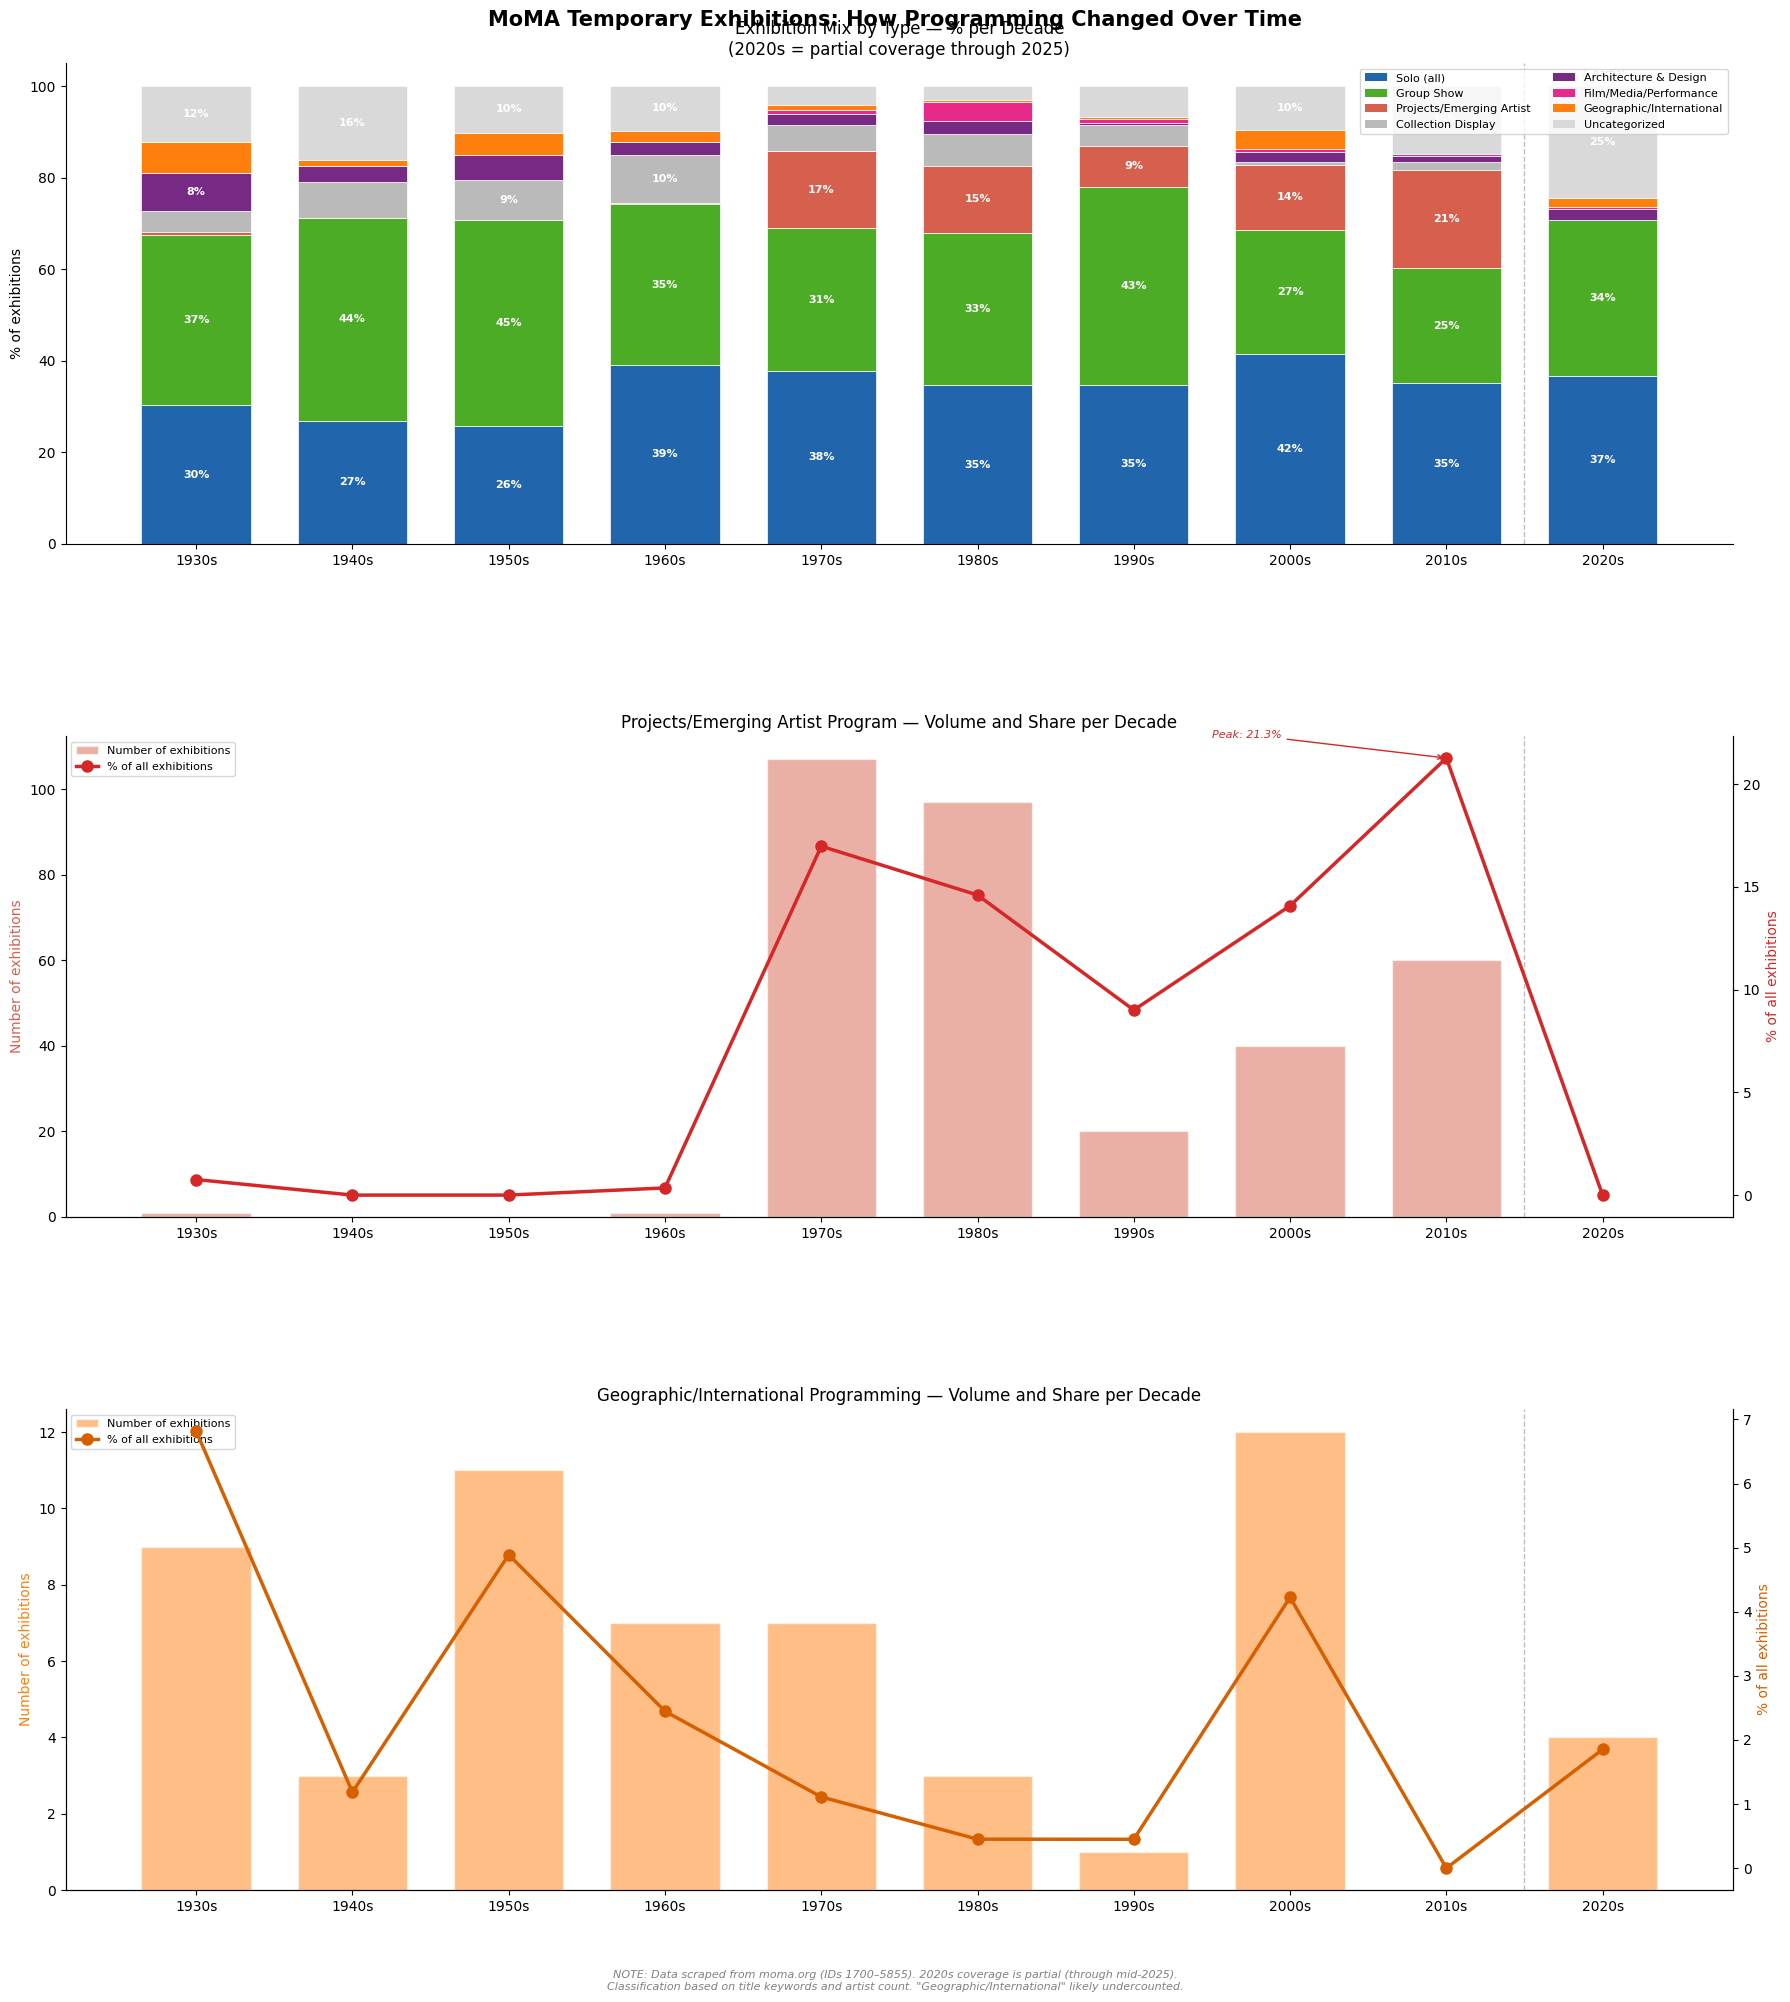

Saved.


In [45]:
fig, axes = plt.subplots(3, 1, figsize=(18, 20))
fig.suptitle('MoMA Temporary Exhibitions: How Programming Changed Over Time',
             fontsize=15, fontweight='bold')

# Include all decades including 2020s
exh_clean = exh_df[
    (exh_df['decade'].notna()) & 
    (exh_df['decade'] >= 1930)
].copy()
exh_clean['decade_label'] = exh_clean['decade'].astype(int).astype(str) + 's'

decade_type = exh_clean.groupby(['decade_label', 'type_final']).size().unstack(fill_value=0)

# Merge Solo types
decade_type['Solo (all)'] = (
    decade_type.get('Solo Show', 0) + 
    decade_type.get('Solo Show (unconfirmed)', 0)
)
decade_type = decade_type.drop(
    columns=['Solo Show', 'Solo Show (unconfirmed)'], errors='ignore')

# Normalize to %
plot_types = ['Solo (all)', 'Group Show', 'Projects/Emerging Artist',
              'Collection Display', 'Architecture & Design',
              'Film/Media/Performance', 'Geographic/International',
              'Uncategorized']
plot_colors = ['#2166ac', '#4dac26', '#d6604d', '#bababa',
               '#762a83', '#e7298a', '#ff7f0e', '#d9d9d9']

available_types = [t for t in plot_types if t in decade_type.columns]
decade_pct = decade_type[available_types].div(
    decade_type[available_types].sum(axis=1), axis=0) * 100

x = range(len(decade_pct))
decade_labels = list(decade_pct.index)

# ── Chart 1: Mix % stacked bar ──
ax1 = axes[0]
bottom = [0] * len(decade_pct)

for t, color in zip(available_types, plot_colors):
    if t in decade_pct.columns:
        vals = decade_pct[t].values
        ax1.bar(x, vals, bottom=bottom, color=color,
                label=t, edgecolor='white', linewidth=0.5, width=0.7)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 8:
                ax1.text(i, b + v/2, f'{v:.0f}%',
                        ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom = [b + v for b, v in zip(bottom, vals)]

ax1.set_xticks(x)
ax1.set_xticklabels(decade_labels, fontsize=10)
ax1.set_title('Exhibition Mix by Type — % per Decade\n(2020s = partial coverage through 2025)',
              fontsize=12)
ax1.set_ylabel('% of exhibitions')
ax1.set_ylim(0, 105)
ax1.axvline(x=len(decade_labels)-1.5, color='gray', 
            linestyle='--', linewidth=1, alpha=0.5)
ax1.text(len(decade_labels)-1, 102, '⚠ partial',
         ha='center', fontsize=7, color='gray', style='italic')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) 
                   for t, c in zip(available_types, plot_colors)]
ax1.legend(handles=legend_elements, fontsize=8, loc='upper right', ncol=2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Projects/Emerging % over time ──
ax2 = axes[1]
ax2_twin = ax2.twinx()

proj_count = decade_type.get('Projects/Emerging Artist',
                              pd.Series([0]*len(decade_type), 
                                        index=decade_type.index))
proj_pct = decade_pct.get('Projects/Emerging Artist',
                           pd.Series([0]*len(decade_pct), 
                                     index=decade_pct.index))

ax2.bar(x, proj_count.values, color='#d6604d', alpha=0.5,
        edgecolor='white', width=0.7, label='Number of exhibitions')
ax2_twin.plot(x, proj_pct.values, color='#d62728',
              marker='o', linewidth=2.5, markersize=8,
              label='% of all exhibitions')

ax2.set_xticks(x)
ax2.set_xticklabels(decade_labels, fontsize=10)
ax2.set_title('Projects/Emerging Artist Program — Volume and Share per Decade',
              fontsize=12)
ax2.set_ylabel('Number of exhibitions', color='#d6604d')
ax2_twin.set_ylabel('% of all exhibitions', color='#d62728')

# Annotate peak and 2020s
peak_idx = list(proj_pct.values).index(max(proj_pct.values))
ax2_twin.annotate(f'Peak: {proj_pct.values[peak_idx]:.1f}%',
                  xy=(peak_idx, proj_pct.values[peak_idx]),
                  xytext=(peak_idx - 1.5, proj_pct.values[peak_idx] + 1),
                  fontsize=8, color='#d62728', style='italic',
                  arrowprops=dict(arrowstyle='->', color='#d62728'))

ax2.axvline(x=len(decade_labels)-1.5, color='gray',
            linestyle='--', linewidth=1, alpha=0.5)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
ax2.spines['top'].set_visible(False)
ax2_twin.spines['top'].set_visible(False)

# ── Chart 3: Geographic/International % over time ──
ax3 = axes[2]
ax3_twin = ax3.twinx()

geo_count = decade_type.get('Geographic/International',
                             pd.Series([0]*len(decade_type),
                                       index=decade_type.index))
geo_pct = decade_pct.get('Geographic/International',
                          pd.Series([0]*len(decade_pct),
                                    index=decade_pct.index))

ax3.bar(x, geo_count.values, color='#ff7f0e', alpha=0.5,
        edgecolor='white', width=0.7, label='Number of exhibitions')
ax3_twin.plot(x, geo_pct.values, color='#d65f00',
              marker='o', linewidth=2.5, markersize=8,
              label='% of all exhibitions')

ax3.set_xticks(x)
ax3.set_xticklabels(decade_labels, fontsize=10)
ax3.set_title('Geographic/International Programming — Volume and Share per Decade',
              fontsize=12)
ax3.set_ylabel('Number of exhibitions', color='#ff7f0e')
ax3_twin.set_ylabel('% of all exhibitions', color='#d65f00')

ax3.axvline(x=len(decade_labels)-1.5, color='gray',
            linestyle='--', linewidth=1, alpha=0.5)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
ax3.spines['top'].set_visible(False)
ax3_twin.spines['top'].set_visible(False)

fig.text(0.5, -0.01,
         'NOTE: Data scraped from moma.org (IDs 1700–5855). '
         '2020s coverage is partial (through mid-2025).\n'
         'Classification based on title keywords and artist count. '
         '"Geographic/International" likely undercounted.',
         ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.04, hspace=0.4)
plt.savefig('data/scraped/exhibitions_programming_change.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [46]:
# 1) Projects/Emerging in 2010s — who are the artists and where are they from?
print("=== PROJECTS/EMERGING ARTIST — 2010s ===\n")

proj_2010s = exh_df[
    (exh_df['decade'] == 2010) & 
    (exh_df['type_final'] == 'Projects/Emerging Artist')
].copy()

print(f"Total: {len(proj_2010s)}")
print(f"\nExhibitions:")
for _, row in proj_2010s.sort_values('year').iterrows():
    print(f"  {int(row['year'])} — {row['title'][:60]}")

# 2) Geographic/International in 2020s — what are they?
print("\n\n=== GEOGRAPHIC/INTERNATIONAL — 2020s ===\n")

geo_2020s = exh_df[
    (exh_df['decade'] == 2020) & 
    (exh_df['type_final'] == 'Geographic/International')
].copy()

print(f"Total: {len(geo_2020s)}")
print(f"\nExhibitions:")
for _, row in geo_2020s.sort_values('year').iterrows():
    print(f"  {int(row['year'])} — {row['title'][:60]}")

# 3) Projects/Emerging in 2020s — why so few?
print("\n\n=== PROJECTS/EMERGING ARTIST — 2020s ===\n")

proj_2020s = exh_df[
    (exh_df['decade'] == 2020) & 
    (exh_df['type_final'] == 'Projects/Emerging Artist')
].copy()

print(f"Total: {len(proj_2020s)}")
if len(proj_2020s) > 0:
    for _, row in proj_2020s.sort_values('year').iterrows():
        print(f"  {int(row['year'])} — {row['title'][:60]}")

# 4) What IS in 2020s?
print("\n\n=== ALL 2020s EXHIBITIONS BY TYPE ===\n")
exh_2020s = exh_df[exh_df['decade'] == 2020].copy()
print(exh_2020s['type_final'].value_counts())
print(f"\nAll 2020s exhibitions:")
for _, row in exh_2020s.sort_values('year').iterrows():
    print(f"  {int(row['year'])} | {row['type_final']:<30} | {row['title'][:50]}")

=== PROJECTS/EMERGING ARTIST — 2010s ===

Total: 60

Exhibitions:
  2011 — Young Architects Program 2011, MAXXI, Rome
  2011 — Young Architects Program 2010, CONSTRUCTO, Santiago
  2012 — Young Architects Program 2012, MAXXI, Rome
  2012 — Young Architects Program 2011, CONSTRUCTO, Santiago
  2013 — Young Architects Program 2013, Istanbul Modern
  2013 — Young Architects Program 2013, MAXXI, Rome
  2013 — Young Architects Program 2012, CONSTRUCTO, Santiago
  2014 — Inbox: British Printed Textiles
  2014 — Inbox: Haegue Yang, Spice Moons
  2014 — Inbox: Lari Pittman, Flying Carpet with Magic Mirrors
  2014 — Inbox: Thomas Ruff
  2014 — Young Architects Program 2014, MMCA, Seoul
  2014 — Young Architects Program 2014, MAXXI, Rome
  2014 — Young Architects Program 2014  Hy-Fi by The Living
  2014 — Young Architects Program 2013, CONSTRUCTO, Santiago
  2015 — Young Architects Program 2014, CONSTRUCTO, Santiago
  2015 — Inbox: Merce Cunningham
  2015 — Young Architects Program 2015, MAXXI, 

In [47]:
import pandas as pd
import json
import re

# Load exhibitions
with open('data/scraped/exhibitions_raw.json') as f:
    exhibitions = json.load(f)

# Load collection
df_art = pd.read_csv('/Users/arousell/collection/Artworks.csv', low_memory=False)
df_art['ConstituentID'] = df_art['ConstituentID'].astype(str)
df_art['YearAcquired'] = pd.to_datetime(df_art['DateAcquired'], errors='coerce').dt.year

# Build exhibition flat table
def extract_year(date_str):
    if not date_str:
        return None
    years = re.findall(r'\b(19\d{2}|20\d{2})\b', date_str)
    return int(years[0]) if years else None

exh_rows = []
for ex in exhibitions:
    year = extract_year(ex.get('date', ''))
    for artist in ex.get('artists', []):
        name = artist.get('name', '').strip().split('\n')[0].strip()
        if name and name.lower() != 'artists':
            exh_rows.append({
                'exhibition_id': ex['id'],
                'exhibition_title': ex['title'].replace('\n', ' ').strip(),
                'exhibition_year': year,
                'artist_name': name,
                'artist_id': artist.get('id', '')
            })

exh_df = pd.DataFrame(exh_rows)

# Focus: exhibitions from 2000 onwards
exh_2000s = exh_df[exh_df['exhibition_year'] >= 2000].copy()
exh_2020s = exh_df[exh_df['exhibition_year'] >= 2020].copy()

print(f"Exhibition-artist pairs 2000+: {len(exh_2000s):,}")
print(f"Unique artists exhibited 2000+: {exh_2000s['artist_name'].nunique():,}")
print(f"\nExhibition-artist pairs 2020+: {len(exh_2020s):,}")
print(f"Unique artists exhibited 2020+: {exh_2020s['artist_name'].nunique():,}")

# Cross-reference with collection by artist_id
# Artists in collection
collection_artists = df_art.groupby('ConstituentID').agg(
    first_acquired=('YearAcquired', 'min'),
    total_works=('Title', 'count'),
    nationality=('Nationality', 'first'),
    artist_name=('Artist', 'first')
).reset_index()

print(f"\nUnique artists in collection: {len(collection_artists):,}")

# Cross by artist_id
exh_2000s['in_collection'] = exh_2000s['artist_id'].isin(
    collection_artists['ConstituentID'])

print(f"\n=== 2000s EXHIBITIONS: COLLECTION CROSSOVER ===")
print(f"Artists exhibited 2000+: {exh_2000s['artist_name'].nunique():,}")
print(f"Of those, in permanent collection: {exh_2000s[exh_2000s['in_collection']]['artist_name'].nunique():,}")
print(f"NOT in collection: {exh_2000s[~exh_2000s['in_collection']]['artist_name'].nunique():,}")

exh_2020s['in_collection'] = exh_2020s['artist_id'].isin(
    collection_artists['ConstituentID'])

print(f"\n=== 2020s EXHIBITIONS: COLLECTION CROSSOVER ===")
print(f"Artists exhibited 2020+: {exh_2020s['artist_name'].nunique():,}")
print(f"Of those, in permanent collection: {exh_2020s[exh_2020s['in_collection']]['artist_name'].nunique():,}")
print(f"NOT in collection: {exh_2020s[~exh_2020s['in_collection']]['artist_name'].nunique():,}")

Exhibition-artist pairs 2000+: 1,580
Unique artists exhibited 2000+: 1,389

Exhibition-artist pairs 2020+: 485
Unique artists exhibited 2020+: 430

Unique artists in collection: 14,389

=== 2000s EXHIBITIONS: COLLECTION CROSSOVER ===
Artists exhibited 2000+: 1,389
Of those, in permanent collection: 669
NOT in collection: 722

=== 2020s EXHIBITIONS: COLLECTION CROSSOVER ===
Artists exhibited 2020+: 430
Of those, in permanent collection: 247
NOT in collection: 183


In [48]:
# For artists IN collection — when did they enter vs when they were exhibited?
print("=== TIMING: EXHIBITION vs COLLECTION ENTRY ===\n")

for period, exh_data in [('2000s+', exh_2000s), ('2020s+', exh_2020s)]:
    print(f"\n{'='*50}")
    print(f"{period}")
    print(f"{'='*50}")
    
    in_coll = exh_data[exh_data['in_collection']].copy()
    
    # Merge with collection to get acquisition year
    in_coll = in_coll.merge(
        collection_artists[['ConstituentID', 'first_acquired']],
        left_on='artist_id', right_on='ConstituentID', how='left'
    )
    
    in_coll['gap'] = in_coll['first_acquired'] - in_coll['exhibition_year']
    
    # Categories
    before = in_coll[in_coll['gap'] < 0]   # in collection BEFORE exhibition
    same = in_coll[in_coll['gap'] == 0]     # same year
    after = in_coll[in_coll['gap'] > 0]     # entered collection AFTER exhibition
    
    total = len(in_coll['artist_name'].unique())
    
    print(f"\nTotal artists exhibited + in collection: {total}")
    print(f"  Already in collection BEFORE exhibition: {before['artist_name'].nunique()} ({before['artist_name'].nunique()/total*100:.0f}%)")
    print(f"  Entered collection SAME year as exhibition: {same['artist_name'].nunique()} ({same['artist_name'].nunique()/total*100:.0f}%)")
    print(f"  Entered collection AFTER exhibition: {after['artist_name'].nunique()} ({after['artist_name'].nunique()/total*100:.0f}%)")
    
    # Gap analysis for "after" group
    after_unique = after.groupby('artist_name')['gap'].min().reset_index()
    print(f"\n  Gap for artists who entered AFTER (years):")
    print(f"    Median: {after_unique['gap'].median():.0f} yrs")
    print(f"    Average: {after_unique['gap'].mean():.1f} yrs")
    print(f"    Within 1 year: {(after_unique['gap'] <= 1).sum()}")
    print(f"    Within 3 years: {(after_unique['gap'] <= 3).sum()}")
    print(f"    Within 5 years: {(after_unique['gap'] <= 5).sum()}")
    print(f"    More than 5 years: {(after_unique['gap'] > 5).sum()}")

print(f"\n\n=== ARTISTS EXHIBITED 2020s BUT NOT IN COLLECTION ===")
not_in = exh_2020s[~exh_2020s['in_collection']]['artist_name'].unique()
print(f"Total: {len(not_in)}")
print(f"\nSample (first 30):")
for name in sorted(not_in)[:30]:
    print(f"  {name}")

=== TIMING: EXHIBITION vs COLLECTION ENTRY ===


2000s+

Total artists exhibited + in collection: 669
  Already in collection BEFORE exhibition: 521 (78%)
  Entered collection SAME year as exhibition: 40 (6%)
  Entered collection AFTER exhibition: 120 (18%)

  Gap for artists who entered AFTER (years):
    Median: 3 yrs
    Average: 4.7 yrs
    Within 1 year: 35
    Within 3 years: 66
    Within 5 years: 87
    More than 5 years: 33

2020s+

Total artists exhibited + in collection: 247
  Already in collection BEFORE exhibition: 221 (89%)
  Entered collection SAME year as exhibition: 12 (5%)
  Entered collection AFTER exhibition: 13 (5%)

  Gap for artists who entered AFTER (years):
    Median: 1 yrs
    Average: 1.2 yrs
    Within 1 year: 11
    Within 3 years: 13
    Within 5 years: 13
    More than 5 years: 0


=== ARTISTS EXHIBITED 2020s BUT NOT IN COLLECTION ===
Total: 183

Sample (first 30):
  Aaron Horkey
  Adjaye Associates
  Adrien Panadis
  Aimé Césaire
  Akan peoples, Ghana
 

In [49]:
print("=== 183 ARTISTS EXHIBITED 2020s — NOT IN COLLECTION ===\n")

not_in_df = exh_2020s[~exh_2020s['in_collection']].copy()

# Show with exhibition details
not_in_detail = not_in_df.groupby('artist_name').agg(
    exhibitions=('exhibition_title', lambda x: list(x)),
    years=('exhibition_year', lambda x: sorted(list(x))),
    num_exhibitions=('exhibition_title', 'count')
).reset_index()

not_in_detail = not_in_detail.sort_values('num_exhibitions', ascending=False)

print(f"Artists with multiple exhibitions but NOT in collection:")
multiple = not_in_detail[not_in_detail['num_exhibitions'] > 1]
print(f"Total: {len(multiple)}")
for _, row in multiple.iterrows():
    print(f"\n  {row['artist_name']} — {row['num_exhibitions']} exhibitions")
    for exh, yr in zip(row['exhibitions'], row['years']):
        print(f"    {yr}: {exh[:60]}")

print(f"\n\n=== ARTISTS ENTERED COLLECTION AFTER 2020s EXHIBITION ===")
in_coll_2020 = exh_2020s[exh_2020s['in_collection']].copy()
in_coll_2020 = in_coll_2020.merge(
    collection_artists[['ConstituentID', 'first_acquired', 'total_works']],
    left_on='artist_id', right_on='ConstituentID', how='left'
)
after_2020 = in_coll_2020[in_coll_2020['first_acquired'] >= in_coll_2020['exhibition_year']]
after_unique = after_2020.groupby('artist_name').agg(
    exhibition_year=('exhibition_year', 'min'),
    acquired_year=('first_acquired', 'min'),
    exhibition=('exhibition_title', 'first'),
    total_works=('total_works', 'first')
).reset_index()
after_unique['gap'] = after_unique['acquired_year'] - after_unique['exhibition_year']
after_unique = after_unique.sort_values('gap')

print(f"\nTotal: {len(after_unique)}")
print(f"\n{'Artist':<35} {'Exhibited':>10} {'Acquired':>10} {'Gap':>5} {'Works':>6}")
print("-" * 70)
for _, row in after_unique.iterrows():
    print(f"{row['artist_name'][:34]:<35} "
          f"{int(row['exhibition_year']):>10} "
          f"{int(row['acquired_year']):>10} "
          f"{int(row['gap']):>4}y "
          f"{int(row['total_works']):>6}")

=== 183 ARTISTS EXHIBITED 2020s — NOT IN COLLECTION ===

Artists with multiple exhibitions but NOT in collection:
Total: 19

  Aaron Horkey — 2 exhibitions
    2022.0: Guillermo del Toro  Crafting Pinocchio
    2022.0: Guillermo del Toro  Crafting Pinocchio (en español)

  Ugo Mulas — 2 exhibitions
    2025.0: Wifredo Lam  When I Don’t Sleep, I Dream
    2025.0: Wifredo Lam  When I Don’t Sleep, I Dream (en español)

  Kavery Kaul — 2 exhibitions
    2024.0: Pacita Abad
    2024.0: Pacita Abad (en español)

  Jasmine Gregory — 2 exhibitions
    2024.0: Jasmine Gregory  Who wants to die for glamour
    2024.0: Jasmine Gregory  Who wants to die for glamour

  Héctor Velázquez — 2 exhibitions
    2024.0: Crafting Modernity  Design in Latin America, 1940–1980
    2024.0: Crafting Modernity  Design in Latin America, 1940–1980 (en e

  Grupo de — 2 exhibitions
    2024.0: Crafting Modernity  Design in Latin America, 1940–1980
    2024.0: Crafting Modernity  Design in Latin America, 1940–1980 

In [31]:
print(f"\nOther remaining: {(exh_df['type2']=='Other').sum()} ({(exh_df['type2']=='Other').sum()/len(exh_df)*100:.1f}%)")
print("\n=== SAMPLE OF 'OTHER' TITLES ===")
print(exh_df[exh_df['type2']=='Other']['title'].sample(20).tolist())



Other remaining: 676 (22.6%)

=== SAMPLE OF 'OTHER' TITLES ===
['People Watching', 'member  Pope.L, 1978–2001', 'Around Picasso', 'Jean Dupuy: A Tower in the Auditorium of P.S. 1', 'Andrei Khlobistin: At Home', 'January Concerts', 'School of Visual Arts End of Year Exhibition', 'New Art for the New Year', 'The Ballet Today', 'Short Cuts', 'Michael Tracy: Terminal Privileges/Privilegios Terminales', 'Three Artists from Bohemia: Art Against False Consciousness', 'Warm Up (2004)', 'Homer, Ryder, and Eakins', 'Paintings and Sculpture from the Museum Collection', 'Paul Klee', 'Lionel Maunz', 'Person Remunerated for a Period of 360 Consecutive Hours', 'The Proscenium: The Staged works of Ida Applebroog, Manny Farber, and Patricia Patterson', 'Poetry (Winter 1978– 1979): Kenneth Deifik and Michael Robbins']


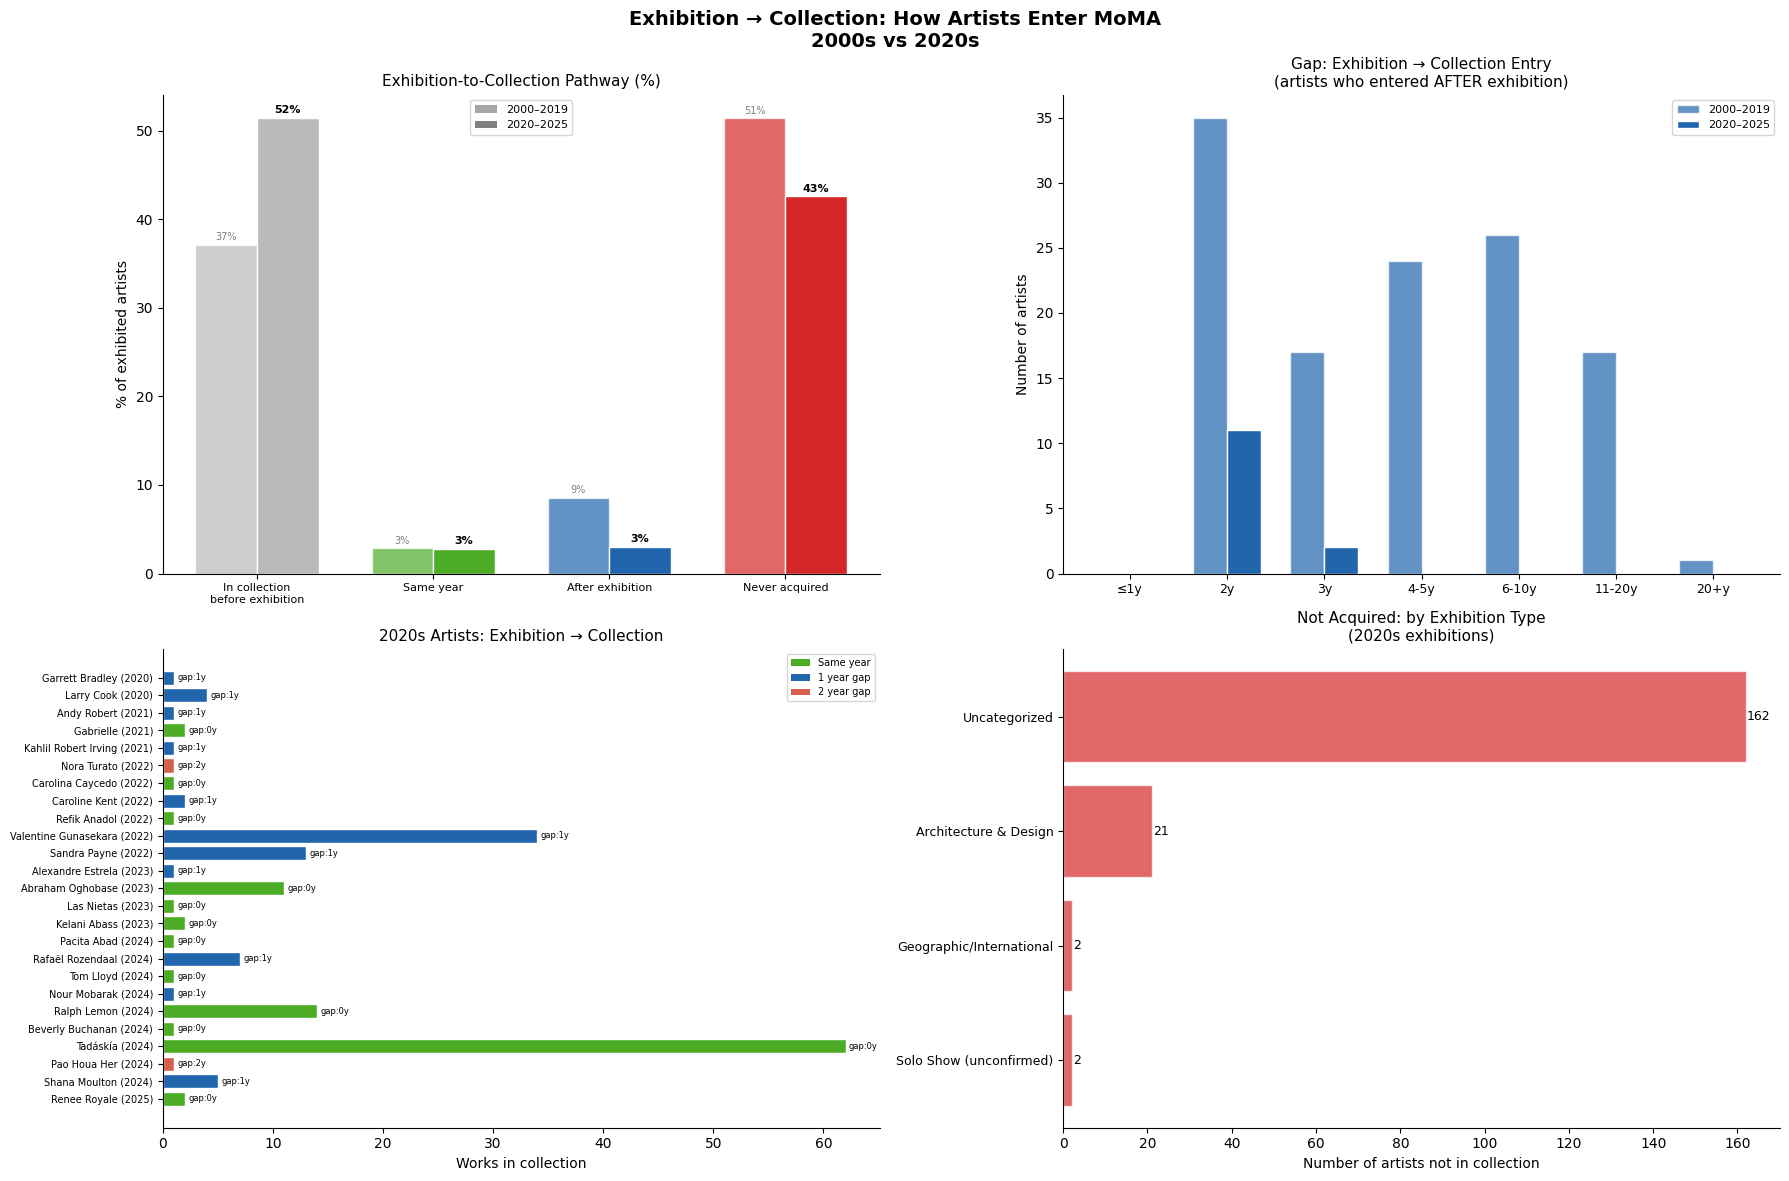

Saved.


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Exhibition → Collection: How Artists Enter MoMA\n2000s vs 2020s',
             fontsize=14, fontweight='bold')

# Chart 1
ax1 = axes[0, 0]
categories = ['In collection\nbefore exhibition','Same year',
              'After exhibition','Never acquired']
vals_2000s = [521, 40, 120, 722]
vals_2020s = [221, 12, 13, 183]
total_2000s = sum(vals_2000s)
total_2020s = sum(vals_2020s)
pct_2000s = [v/total_2000s*100 for v in vals_2000s]
pct_2020s = [v/total_2020s*100 for v in vals_2020s]
x = range(len(categories))
width = 0.35
colors = ['#bababa', '#4dac26', '#2166ac', '#d62728']
bars1 = ax1.bar([i-width/2 for i in x], pct_2000s, width=width, color=colors, alpha=0.7, edgecolor='white')
bars2 = ax1.bar([i+width/2 for i in x], pct_2020s, width=width, color=colors, alpha=1.0, edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=8)
ax1.set_title('Exhibition-to-Collection Pathway (%)', fontsize=11)
ax1.set_ylabel('% of exhibited artists')
for bar, val in zip(bars1, pct_2000s):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.0f}%', ha='center', fontsize=7, color='gray')
for bar, val in zip(bars2, pct_2020s):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold')
ax1.legend(handles=[mpatches.Patch(facecolor='gray', alpha=0.7, label='2000–2019'),
                    mpatches.Patch(facecolor='gray', alpha=1.0, label='2020–2025')], fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Chart 2
ax2 = axes[0, 1]
in_coll_2000s = exh_2000s[exh_2000s['in_collection']].copy()
in_coll_2000s = in_coll_2000s.merge(collection_artists[['ConstituentID','first_acquired']],
    left_on='artist_id', right_on='ConstituentID', how='left')
in_coll_2000s['gap'] = in_coll_2000s['first_acquired'] - in_coll_2000s['exhibition_year']
after_2000s_gaps = in_coll_2000s[in_coll_2000s['gap'] > 0].groupby('artist_name')['gap'].min()
after_2020s_gaps = after_unique[after_unique['gap'] > 0]['gap']
bins = [0, 1, 2, 3, 5, 10, 20, 50]
labels_bins = ['≤1y', '2y', '3y', '4-5y', '6-10y', '11-20y', '20+y']
hist_2000s, _ = np.histogram(after_2000s_gaps, bins=bins)
hist_2020s, _ = np.histogram(after_2020s_gaps, bins=bins)
x2 = range(len(labels_bins))
ax2.bar([i-width/2 for i in x2], hist_2000s, width=width, color='#2166ac', alpha=0.7, label='2000–2019', edgecolor='white')
ax2.bar([i+width/2 for i in x2], hist_2020s, width=width, color='#2166ac', alpha=1.0, label='2020–2025', edgecolor='white')
ax2.set_xticks(x2)
ax2.set_xticklabels(labels_bins, fontsize=9)
ax2.set_title('Gap: Exhibition → Collection Entry\n(artists who entered AFTER exhibition)', fontsize=11)
ax2.set_ylabel('Number of artists')
ax2.legend(fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Chart 3
ax3 = axes[1, 0]
after_unique_sorted = after_unique.sort_values('exhibition_year')
colors_gap = ['#4dac26' if g==0 else '#2166ac' if g==1 else '#d6604d' for g in after_unique_sorted['gap']]
bars3 = ax3.barh(range(len(after_unique_sorted)), after_unique_sorted['total_works'],
                 color=colors_gap, edgecolor='white')
ax3.set_yticks(range(len(after_unique_sorted)))
ax3.set_yticklabels([f"{row['artist_name'][:25]} ({int(row['exhibition_year'])})"
                     for _, row in after_unique_sorted.iterrows()], fontsize=7)
ax3.invert_yaxis()
ax3.set_title('2020s Artists: Exhibition → Collection', fontsize=11)
ax3.set_xlabel('Works in collection')
for bar, (_, row) in zip(bars3, after_unique_sorted.iterrows()):
    ax3.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f"gap:{int(row['gap'])}y", va='center', fontsize=6)
ax3.legend(handles=[mpatches.Patch(facecolor='#4dac26', label='Same year'),
                    mpatches.Patch(facecolor='#2166ac', label='1 year gap'),
                    mpatches.Patch(facecolor='#d6604d', label='2 year gap')], fontsize=7)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Chart 4
ax4 = axes[1, 1]
not_in_2020 = exh_2020s[~exh_2020s['in_collection']].copy()
not_in_2020['type'] = not_in_2020['exhibition_title'].apply(
    lambda t: classify_exhibition_v3(t.replace('\n',' '), 0))
not_in_by_type = not_in_2020.groupby('type')['artist_name'].nunique().sort_values(ascending=False)
bars4 = ax4.barh(range(len(not_in_by_type)), not_in_by_type.values,
                 color='#d62728', alpha=0.7, edgecolor='white')
ax4.set_yticks(range(len(not_in_by_type)))
ax4.set_yticklabels(not_in_by_type.index, fontsize=9)
ax4.invert_yaxis()
ax4.set_title('Not Acquired: by Exhibition Type\n(2020s exhibitions)', fontsize=11)
ax4.set_xlabel('Number of artists not in collection')
for bar, val in zip(bars4, not_in_by_type.values):
    ax4.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, str(val), va='center', fontsize=9)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/scraped/exhibition_collection_crossover.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [20]:
import pandas as pd
import json

# Load scraped exhibitions
with open('data/scraped/exhibitions_raw.json') as f:
    exhibitions = json.load(f)

# Build a flat table: exhibition + artist
rows = []
for ex in exhibitions:
    for artist in ex.get('artists', []):
        name = artist.get('name', '').strip().split('\n')[0].strip()
        if name and name.lower() != 'artists':
            rows.append({
                'exhibition_id': ex['id'],
                'exhibition_title': ex['title'],
                'date': ex.get('date', ''),
                'artist_name': name,
                'artist_id': artist.get('id', '')
            })

exh_df = pd.DataFrame(rows)

print(f"Total exhibition-artist pairs: {len(exh_df):,}")
print(f"Unique exhibitions: {exh_df['exhibition_id'].nunique():,}")
print(f"Unique artists: {exh_df['artist_name'].nunique():,}")
print(f"\nSample:")
print(exh_df.head(10).to_string())

Total exhibition-artist pairs: 7,776
Unique exhibitions: 2,596
Unique artists: 4,928

Sample:
   exhibition_id                 exhibition_title                       date        artist_name artist_id
0           1700         Five Recent Acquisitions        Apr 18–Jun 22, 1975    Georges Rouault      5053
1           1700         Five Recent Acquisitions        Apr 18–Jun 22, 1975      Henri Matisse      3832
2           1700         Five Recent Acquisitions        Apr 18–Jun 22, 1975     Pierre Bonnard       665
3           1700         Five Recent Acquisitions        Apr 18–Jun 22, 1975       Edvard Munch      4164
4           1700         Five Recent Acquisitions        Apr 18–Jun 22, 1975    Marie Laurencin      3408
5           1701  The Masterworks of Edvard Munch        Mar 15–Apr 24, 1979       Edvard Munch      4164
6           1702          The Symbolist Aesthetic  Dec 22, 1980–Mar 10, 1981            Balthus       317
7           1702          The Symbolist Aesthetic  Dec 22,

In [23]:
import os

# Find Artworks.csv
for root, dirs, files in os.walk('/'):
    for file in files:
        if file == 'Artworks.csv':
            print(os.path.join(root, file))
    # Skip irrelevant directories
    dirs[:] = [d for d in dirs if d not in ['proc', 'sys', 'dev']]

/System/Volumes/Data/Users/arousell/collection/Artworks.csv
/Users/arousell/collection/Artworks.csv


In [24]:
df_art = pd.read_csv('/Users/arousell/collection/Artworks.csv', low_memory=False)
df_art['ConstituentID'] = df_art['ConstituentID'].astype(str)

# Self-donation mask
self_mask = df_art['CreditLine'].str.contains(
    'gift of the artist|gift of the architect|gift of the architects|'
    'gift of the designer|gift of the manufacturer',
    case=False, na=False
)

self_df = df_art[self_mask].copy()
self_df['YearAcquired'] = pd.to_datetime(self_df['DateAcquired'], errors='coerce').dt.year
self_df['ArtworkYear'] = pd.to_numeric(
    self_df['Date'].str.extract(r'(\d{4})')[0], errors='coerce')

# Get unique artists who self-donated with contemporary works (1999+)
self_recent = self_df[
    (self_df['ArtworkYear'] >= 1999) & 
    (self_df['ArtworkYear'] <= 2026)
].copy()

self_donor_names = set(self_recent['Artist'].str.strip().dropna().tolist())

print(f"Self-donation artists (artwork 1999+): {len(self_donor_names):,}")
print(f"Artists in exhibition dataset: {exh_df['artist_name'].nunique():,}")

# Cross-reference
exh_df['artist_name_clean'] = exh_df['artist_name'].str.strip()
matches = exh_df[exh_df['artist_name_clean'].isin(self_donor_names)]

print(f"\nDirect name matches: {len(matches):,}")
print(f"Unique matching artists: {matches['artist_name_clean'].nunique()}")

if len(matches) > 0:
    print(f"\nMatched artists and exhibitions:")
    for artist in matches['artist_name_clean'].unique():
        artist_exhs = matches[matches['artist_name_clean'] == artist]
        donation_year = self_recent[
            self_recent['Artist'].str.strip() == artist
        ]['YearAcquired'].min()
        print(f"\n  {artist} (donated: {int(donation_year)})")
        for _, row in artist_exhs.sort_values('year').iterrows():
            if row['year']:
                rel = 'BEFORE' if row['year'] < donation_year else 'AFTER'
                print(f"    {rel} — {int(row['year'])} — {row['exhibition_title'][:50]}")

Self-donation artists (artwork 1999+): 413
Artists in exhibition dataset: 4,928

Direct name matches: 139
Unique matching artists: 54

Matched artists and exhibitions:

  Sol LeWitt (donated: 2007)
    BEFORE — 1969 — Recent Acquisitions IV
    BEFORE — 1978 — Recent Acquisitions:
American Prints
    BEFORE — 1978 — Sol LeWitt
    BEFORE — 1981 — Words and Pictures
    BEFORE — 1987 — Contemporary Works
from the Collection
    BEFORE — 1990 — Prints in Parts Since 1970
    BEFORE — 1999 — MoMA2000,
ModernStarts, People:
Sol LeWitt Wall Dr
    BEFORE — 1999 — Sol LeWitt: Concrete Block

  Jasper Johns (donated: 2010)
    BEFORE — 1966 — Paul J. Sachs Gallery
Print Re-Installation
    BEFORE — 1969 — Drawings: Recent
Acquisitions
    BEFORE — 1970 — Jasper Johns: Lithographs
    BEFORE — 1971 — Jasper Johns: Map
    BEFORE — 1972 — Etchings Etc.
    BEFORE — 1973 — Recent Acquisitions,
1968–1973
    BEFORE — 1976 — Drawing Now: 1955–1975
    BEFORE — 1978 — Art for Corporations
    BEFOR

In [25]:
print("=== EXPOSURE BEFORE DONATION: QUANTIFIED ===\n")

before_count = 0
after_count = 0
both_count = 0
only_before = []
only_after = []

for artist in matches['artist_name_clean'].unique():
    artist_exhs = matches[matches['artist_name_clean'] == artist]
    donation_year = self_recent[
        self_recent['Artist'].str.strip() == artist
    ]['YearAcquired'].min()
    
    has_before = any(
        row['year'] and row['year'] < donation_year 
        for _, row in artist_exhs.iterrows()
    )
    has_after = any(
        row['year'] and row['year'] >= donation_year 
        for _, row in artist_exhs.iterrows()
    )
    
    if has_before and has_after:
        both_count += 1
    elif has_before:
        before_count += 1
        only_before.append({
            'artist': artist,
            'donation_year': int(donation_year),
            'exhibitions_before': len(artist_exhs[artist_exhs['year'] < donation_year]),
            'first_exhibition': int(artist_exhs[artist_exhs['year'].notna()]['year'].min())
        })
    elif has_after:
        after_count += 1
        only_after.append({'artist': artist, 'donation_year': int(donation_year)})

total = len(matches['artist_name_clean'].unique())
print(f"Total matched artists: {total}")
print(f"\nExposed BEFORE donation only: {before_count} ({before_count/total*100:.0f}%)")
print(f"Exposed AFTER donation only:  {after_count} ({after_count/total*100:.0f}%)")
print(f"Exposed BOTH before and after: {both_count} ({both_count/total*100:.0f}%)")

print(f"\n=== ARTISTS EXPOSED BEFORE DONATING ===")
print(f"(exhibition → then self-donation)")
for a in sorted(only_before, key=lambda x: x['exhibitions_before'], reverse=True):
    gap = a['donation_year'] - a['first_exhibition']
    print(f"  {a['artist']}: {a['exhibitions_before']} exhs before donation "
          f"({a['first_exhibition']} → donated {a['donation_year']}, gap: {gap} yrs)")

=== EXPOSURE BEFORE DONATION: QUANTIFIED ===

Total matched artists: 54

Exposed BEFORE donation only: 41 (76%)
Exposed AFTER donation only:  5 (9%)
Exposed BOTH before and after: 8 (15%)

=== ARTISTS EXPOSED BEFORE DONATING ===
(exhibition → then self-donation)
  Sol LeWitt: 8 exhs before donation (1969 → donated 2007, gap: 38 yrs)
  Dan Graham: 7 exhs before donation (1975 → donated 2016, gap: 41 yrs)
  Lee Friedlander: 6 exhs before donation (1967 → donated 2003, gap: 36 yrs)
  R. B. Kitaj: 5 exhs before donation (1966 → donated 2005, gap: 39 yrs)
  Michelangelo Pistoletto: 5 exhs before donation (1966 → donated 2009, gap: 43 yrs)
  Kiki Smith: 4 exhs before donation (1981 → donated 2003, gap: 22 yrs)
  Chuck Close: 3 exhs before donation (1973 → donated 2000, gap: 27 yrs)
  Liliana Porter: 2 exhs before donation (1973 → donated 2024, gap: 51 yrs)
  Nicholas Nixon: 2 exhs before donation (1976 → donated 1999, gap: 23 yrs)
  Richard Serra: 2 exhs before donation (1986 → donated 2014,

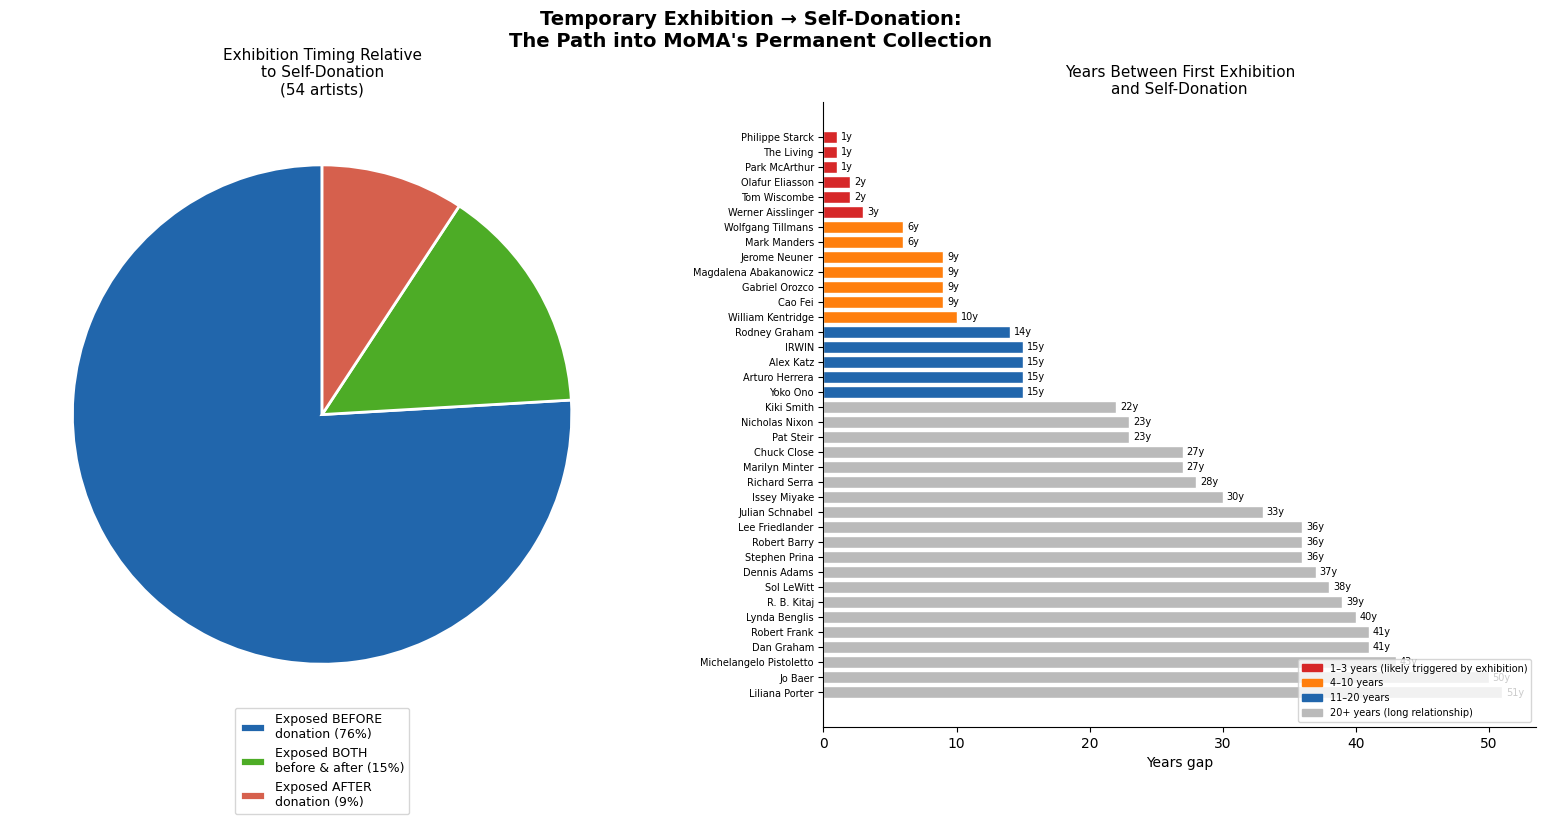

Saved.


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Temporary Exhibition → Self-Donation:\nThe Path into MoMA\'s Permanent Collection',
             fontsize=14, fontweight='bold')

# ── Chart 1: Before / After / Both ──
ax1 = axes[0]
categories_pie = ['Exposed BEFORE\ndonation (76%)',
                  'Exposed BOTH\nbefore & after (15%)',
                  'Exposed AFTER\ndonation (9%)']
sizes = [41, 8, 5]
colors = ['#2166ac', '#4dac26', '#d6604d']
wedges, texts = ax1.pie(sizes, colors=colors, startangle=90,
                         wedgeprops=dict(edgecolor='white', linewidth=2))
ax1.legend(wedges, categories_pie, fontsize=9,
           loc='lower center', bbox_to_anchor=(0.5, -0.15))
ax1.set_title('Exhibition Timing Relative\nto Self-Donation\n(54 artists)', fontsize=11)

# ── Chart 2: Gap distribution ──
ax2 = axes[1]

gaps = [
    ('Philippe Starck', 1), ('The Living', 1), ('Park McArthur', 1),
    ('Olafur Eliasson', 2), ('Tom Wiscombe', 2), ('Werner Aisslinger', 3),
    ('Wolfgang Tillmans', 6), ('Mark Manders', 6), ('Jerome Neuner', 9),
    ('Magdalena Abakanowicz', 9), ('Gabriel Orozco', 9), ('Cao Fei', 9),
    ('IRWIN', 15), ('Alex Katz', 15), ('Arturo Herrera', 15),
    ('Yoko Ono', 15), ('Rodney Graham', 14), ('William Kentridge', 10),
    ('Kiki Smith', 22), ('Nicholas Nixon', 23), ('Pat Steir', 23),
    ('Chuck Close', 27), ('Marilyn Minter', 27), ('Richard Serra', 28),
    ('Issey Miyake', 30), ('Julian Schnabel', 33), ('Lee Friedlander', 36),
    ('Robert Barry', 36), ('Stephen Prina', 36), ('Dennis Adams', 37),
    ('Sol LeWitt', 38), ('R. B. Kitaj', 39), ('Lynda Benglis', 40),
    ('Robert Frank', 41), ('Dan Graham', 41), ('Michelangelo Pistoletto', 43),
    ('Jo Baer', 50), ('Liliana Porter', 51),
]

gaps_sorted = sorted(gaps, key=lambda x: x[1])
names = [g[0] for g in gaps_sorted]
values = [g[1] for g in gaps_sorted]

# Color by gap length
def gap_color(gap):
    if gap <= 3:
        return '#d62728'   # red — very fast
    elif gap <= 10:
        return '#ff7f0e'   # orange — fast
    elif gap <= 20:
        return '#2166ac'   # blue — medium
    else:
        return '#bababa'   # gray — long

colors_gap = [gap_color(v) for v in values]

bars = ax2.barh(range(len(names)), values, color=colors_gap, edgecolor='white')
ax2.set_yticks(range(len(names)))
ax2.set_yticklabels(names, fontsize=7)
ax2.invert_yaxis()
ax2.set_title('Years Between First Exhibition\nand Self-Donation', fontsize=11)
ax2.set_xlabel('Years gap')

for bar, val in zip(bars, values):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}y', va='center', fontsize=7)

legend_elements = [
    mpatches.Patch(color='#d62728', label='1–3 years (likely triggered by exhibition)'),
    mpatches.Patch(color='#ff7f0e', label='4–10 years'),
    mpatches.Patch(color='#2166ac', label='11–20 years'),
    mpatches.Patch(color='#bababa', label='20+ years (long relationship)'),
]
ax2.legend(handles=legend_elements, fontsize=7, loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/scraped/exhibition_to_donation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [60]:
print("=== SELF-DONATIONS 2020s: NATIONALITY PROFILE ===\n")

# Self-donations in collection with artwork 2020+
self_2020 = self_df[
    (self_df['YearAcquired'] >= 2020) &
    (self_df['YearAcquired'] <= 2025)
].copy()

print(f"Total self-donation works 2020-2025: {len(self_2020):,}")
print(f"Unique artists: {self_2020['Artist'].nunique():,}")

print(f"\nBy CreditLine type:")
for pattern, label in [
    ('gift of the artist', 'Gift of the artist'),
    ('gift of the architect', 'Gift of the architect'),
    ('gift of the designer', 'Gift of the designer'),
    ('gift of the manufacturer', 'Gift of the manufacturer'),
]:
    count = self_2020['CreditLine'].str.contains(pattern, case=False, na=False).sum()
    if count > 0:
        print(f"  {label}: {count}")

print(f"\nBy nationality (top 15):")
print(self_2020['Nationality'].value_counts().head(15))

print(f"\nBy department:")
print(self_2020['Department'].value_counts())

print(f"\nUnique artists and their nationality:")
self_2020_artists = self_2020.groupby('Artist').agg(
    nationality=('Nationality', 'first'),
    department=('Department', 'first'),
    works=('Title', 'count'),
    credit=('CreditLine', 'first')
).reset_index().sort_values('works', ascending=False)

for _, row in self_2020_artists.iterrows():
    print(f"  {row['Artist'][:40]} ({row['nationality']}) "
          f"— {row['works']} works — {row['department'][:25]}")
    print(f"    → {str(row['credit'])[:80]}")

=== SELF-DONATIONS 2020s: NATIONALITY PROFILE ===

Total self-donation works 2020-2025: 465
Unique artists: 119

By CreditLine type:
  Gift of the artist: 195
  Gift of the architect: 235
  Gift of the designer: 32
  Gift of the manufacturer: 3

By nationality (top 15):
Nationality
(American)                       169
(Chinese) (Chinese)               44
(Mexican)                         31
(Chinese) (Chinese) (Chinese)     21
(Chinese)                         19
(Polish)                          17
(Dutch)                           13
(Argentine)                       12
()                                11
(Native American)                 10
(Spanish)                         10
(Thai)                            10
(British)                          9
(American) (Mexican)               9
(Thai) ()                          7
Name: count, dtype: int64

By department:
Department
Architecture & Design    287
Drawings & Prints         82
Photography               77
Media and Performance 

In [56]:
print("=== 25 ARTISTS: EXHIBITION → COLLECTION 2020s — HOW DID THEY ENTER? ===\n")

results = []
for _, row in after_unique.iterrows():
    artist_name = row['artist_name']
    exhibition_year = row['exhibition_year']
    acquired_year = row['acquired_year']
    gap = row['gap']
    exhibition = row['exhibition']
    
    # Find in collection by name
    artist_works = df_art[
        df_art['Artist'].str.contains(artist_name.split()[0], na=False, case=False) &
        (df_art['YearAcquired'] == acquired_year)
    ]
    
    if len(artist_works) > 0:
        credit = str(artist_works['CreditLine'].iloc[0]) if pd.notna(artist_works['CreditLine'].iloc[0]) else ''
        dept = str(artist_works['Department'].iloc[0]) if pd.notna(artist_works['Department'].iloc[0]) else ''
        
        credit_lower = credit.lower()
        if any(x in credit_lower for x in ['gift of the artist', 'gift of the architect',
                                             'gift of the designer']):
            acq_type = 'SELF-DONATION'
        elif 'fund' in credit_lower and 'gift' not in credit_lower:
            acq_type = 'PURCHASE (fund)'
        elif 'purchase' in credit_lower:
            acq_type = 'PURCHASE (direct)'
        elif 'gift' in credit_lower:
            acq_type = 'EXTERNAL DONATION'
        else:
            acq_type = 'OTHER'
        
        results.append({
            'artist': artist_name,
            'exhibition': str(exhibition)[:50],
            'exhibition_year': int(exhibition_year),
            'acquired_year': int(acquired_year),
            'gap': int(gap),
            'acquisition_type': acq_type,
            'department': dept,
            'credit_line': credit[:80]
        })
    else:
        results.append({
            'artist': artist_name,
            'exhibition': str(exhibition)[:50],
            'exhibition_year': int(exhibition_year),
            'acquired_year': int(acquired_year),
            'gap': int(gap),
            'acquisition_type': 'NOT MATCHED',
            'department': '',
            'credit_line': ''
        })

results_df = pd.DataFrame(results)

print(f"{'Artist':<25} {'Exh':>5} {'Acq':>5} {'Gap':>4} {'Type':<25} {'Dept':<25}")
print("-" * 95)
for _, row in results_df.sort_values('gap').iterrows():
    print(f"{row['artist'][:24]:<25} {row['exhibition_year']:>5} "
          f"{row['acquired_year']:>5} {row['gap']:>3}y "
          f"{row['acquisition_type']:<25} {row['department'][:24]:<25}")

print(f"\n=== SUMMARY BY ACQUISITION TYPE ===")
print(results_df['acquisition_type'].value_counts())

print(f"\n=== CREDIT LINES ===")
for _, row in results_df[results_df['acquisition_type'] != 'NOT MATCHED'].iterrows():
    print(f"\n  {row['artist']} ({row['acquisition_type']}):")
    print(f"  → {row['credit_line']}")

=== 25 ARTISTS: EXHIBITION → COLLECTION 2020s — HOW DID THEY ENTER? ===

Artist                      Exh   Acq  Gap Type                      Dept                     
-----------------------------------------------------------------------------------------------
Abraham Oghobase           2023  2023   0y OTHER                     Photography              
Pacita Abad                2024  2024   0y EXTERNAL DONATION         Painting & Sculpture     
Tom Lloyd                  2024  2024   0y PURCHASE (fund)           Painting & Sculpture     
Las Nietas                 2023  2023   0y PURCHASE (fund)           Media and Performance    
Kelani Abass               2023  2023   0y PURCHASE (fund)           Photography              
Refik Anadol               2022  2022   0y EXTERNAL DONATION         Media and Performance    
Ralph Lemon                2024  2024   0y OTHER                     Drawings & Prints        
Gabrielle                  2021  2021   0y PURCHASE (fund)           Ph

In [57]:
print("=== FULL ANALYSIS: EXHIBITION → COLLECTION 1999-2025 ===\n")

# All exhibitions from 1999
exh_1999 = exh_df[exh_df['exhibition_year'] >= 1999].copy()

print(f"Total exhibition-artist pairs 1999+: {len(exh_1999):,}")
print(f"Unique artists exhibited 1999+: {exh_1999['artist_name'].nunique():,}")

# Cross with collection
exh_1999['in_collection'] = exh_1999['artist_id'].isin(collection_artists['ConstituentID'])

# Merge acquisition year
exh_1999_merged = exh_1999.merge(
    collection_artists[['ConstituentID', 'first_acquired']],
    left_on='artist_id', right_on='ConstituentID', how='left'
)
exh_1999_merged['gap'] = exh_1999_merged['first_acquired'] - exh_1999_merged['exhibition_year']

# Per year analysis
yearly_results = []
for year in sorted(exh_1999_merged['exhibition_year'].dropna().unique()):
    year_data = exh_1999_merged[exh_1999_merged['exhibition_year'] == year]
    total = year_data['artist_name'].nunique()
    
    in_coll = year_data[year_data['in_collection']]
    
    before = in_coll[in_coll['gap'] < 0]['artist_name'].nunique()
    same = in_coll[in_coll['gap'] == 0]['artist_name'].nunique()
    after = in_coll[in_coll['gap'] > 0]['artist_name'].nunique()
    never = year_data[~year_data['in_collection']]['artist_name'].nunique()
    
    yearly_results.append({
        'year': int(year),
        'total': total,
        'before': before,
        'same_year': same,
        'after': after,
        'never': never,
        'pct_before': before/total*100 if total > 0 else 0,
        'pct_same': same/total*100 if total > 0 else 0,
        'pct_after': after/total*100 if total > 0 else 0,
        'pct_never': never/total*100 if total > 0 else 0,
    })

yearly_df = pd.DataFrame(yearly_results)
print(yearly_df[['year','total','before','same_year','after','never']].to_string())

=== FULL ANALYSIS: EXHIBITION → COLLECTION 1999-2025 ===

Total exhibition-artist pairs 1999+: 1,753
Unique artists exhibited 1999+: 1,524
    year  total  before  same_year  after  never
0   1999    164      75          0     20     69
1   2000     68      13          0     17     36
2   2001     83      11          1     10     61
3   2002     50      10          0     10     30
4   2003     47       7          0      7     33
5   2004     75      15          1     18     41
6   2005     49      17          1      3     28
7   2006     91      40          2      8     40
8   2007     93      32          3      6     52
9   2008     35      13          0      2     20
10  2009     36      19          1      4     12
11  2010     34      12          2      4     16
12  2011     42      22          1      4     15
13  2012     30       6          1      6     17
14  2013     20       8          2      0     10
15  2014     39       7          1      4     27
16  2015     20       4     

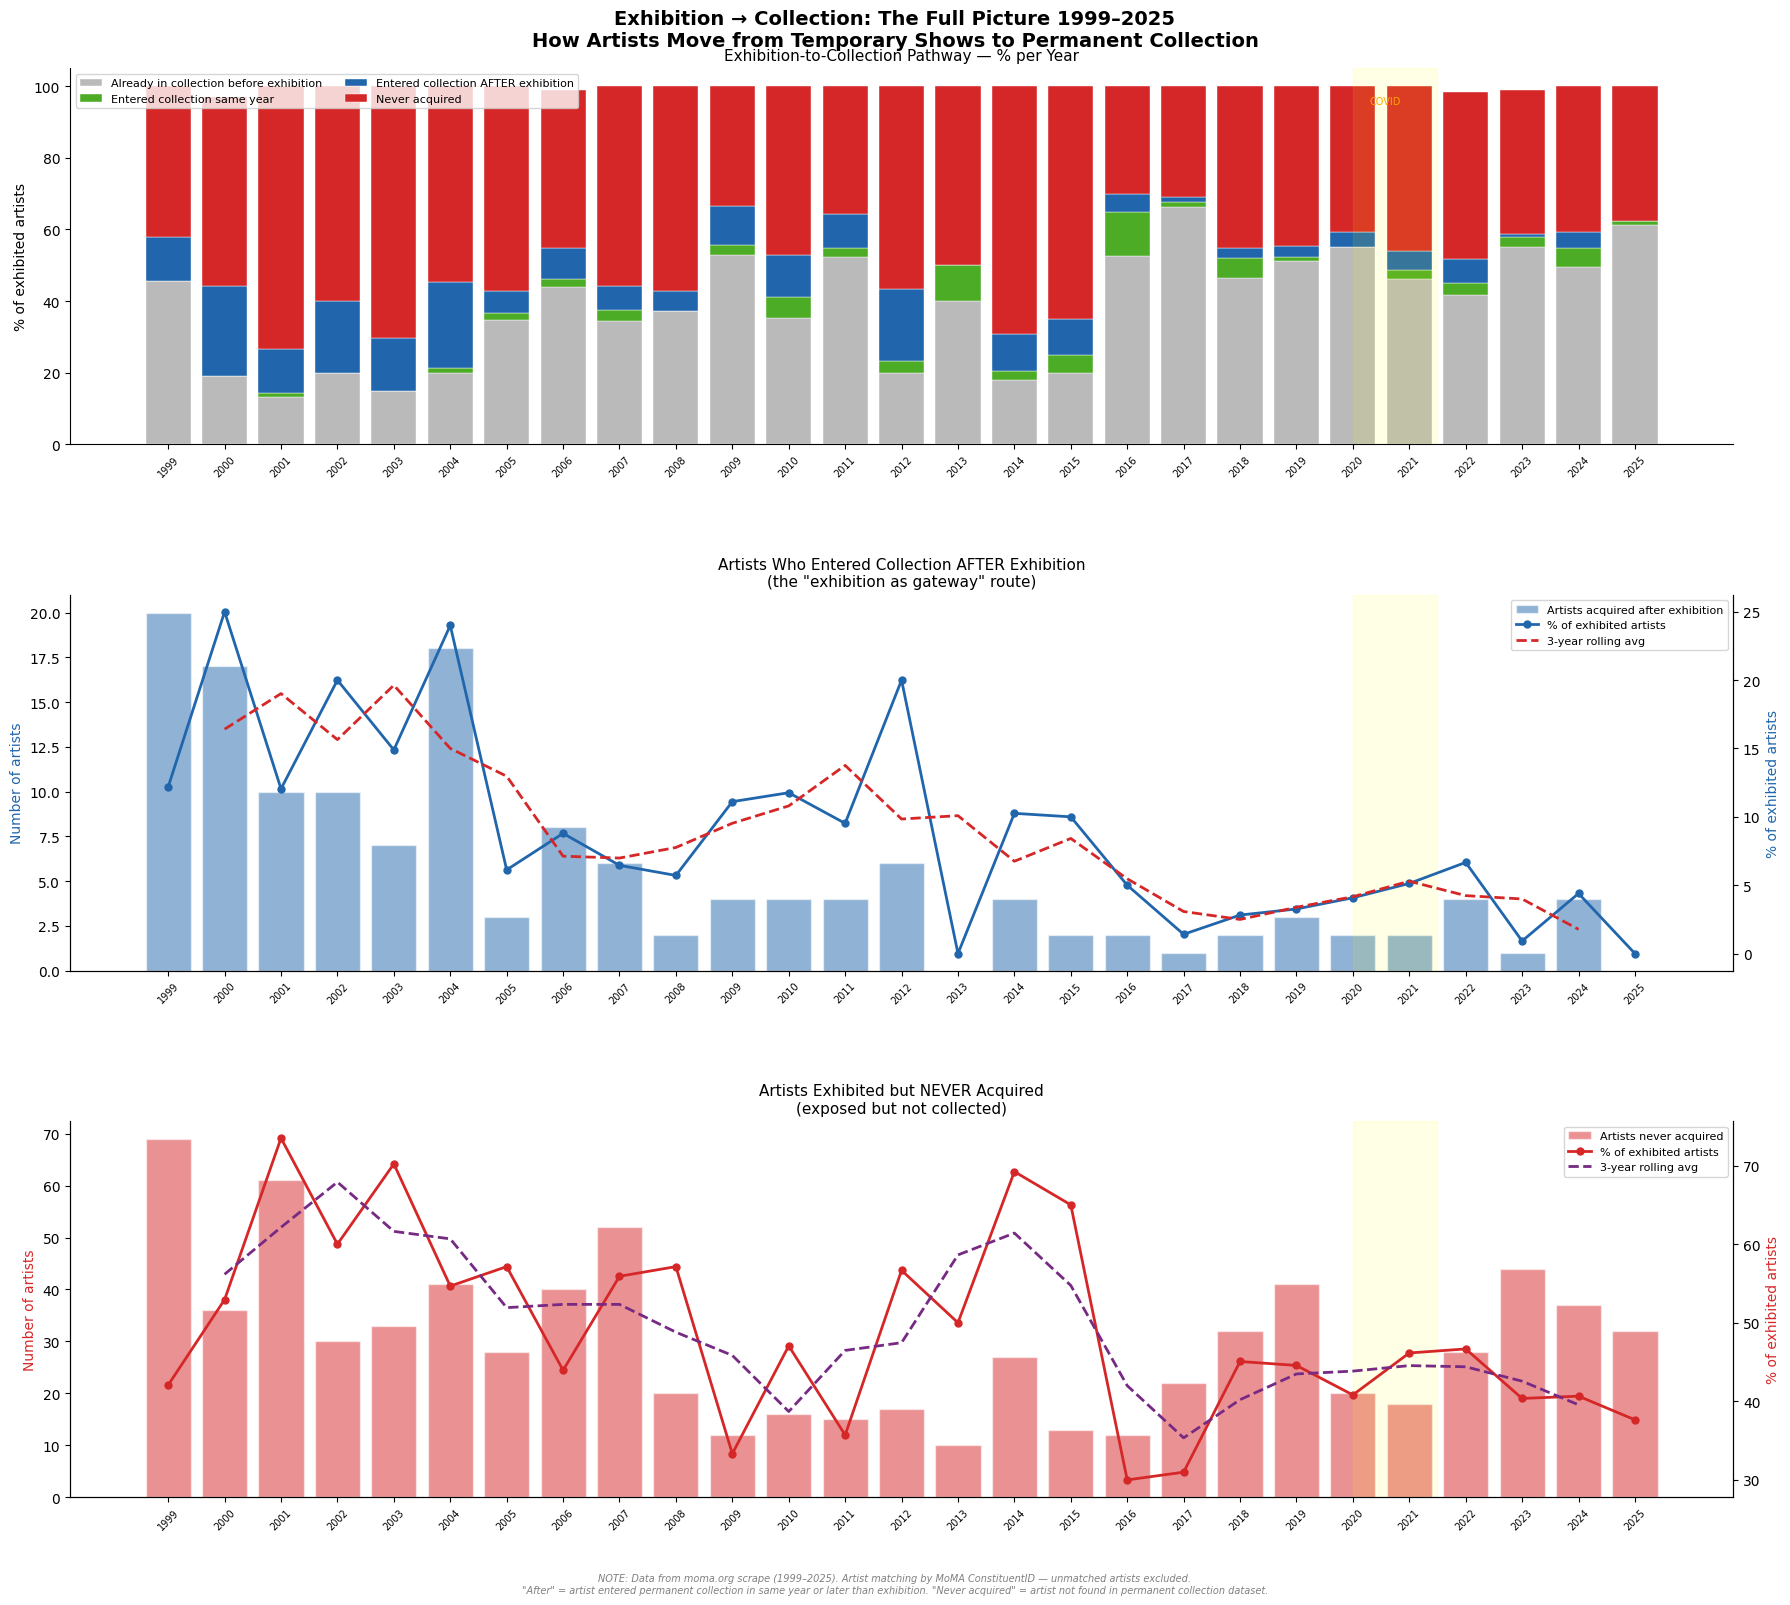

Saved.


In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(18, 16))
fig.suptitle('Exhibition → Collection: The Full Picture 1999–2025\nHow Artists Move from Temporary Shows to Permanent Collection',
             fontsize=14, fontweight='bold')

# Remove 2026 (incomplete year)
yd = yearly_df[yearly_df['year'] <= 2025].copy()

years = yd['year'].astype(str).tolist()
x = range(len(years))

# ── Chart 1: Stacked % area ──
ax1 = axes[0]

colors = {
    'pct_before': '#bababa',
    'pct_same': '#4dac26',
    'pct_after': '#2166ac',
    'pct_never': '#d62728',
}
labels = {
    'pct_before': 'Already in collection before exhibition',
    'pct_same':   'Entered collection same year',
    'pct_after':  'Entered collection AFTER exhibition',
    'pct_never':  'Never acquired',
}

bottom = np.zeros(len(yd))
for col, color in colors.items():
    vals = yd[col].values
    ax1.bar(x, vals, bottom=bottom, color=color,
            label=labels[col], edgecolor='white', linewidth=0.3, width=0.8)
    bottom += vals

ax1.set_xticks(x)
ax1.set_xticklabels(years, rotation=45, fontsize=7)
ax1.set_title('Exhibition-to-Collection Pathway — % per Year', fontsize=11)
ax1.set_ylabel('% of exhibited artists')
ax1.set_ylim(0, 105)
ax1.legend(fontsize=8, loc='upper left', ncol=2)

# Mark COVID
ax1.axvspan(years.index('2020'), years.index('2021')+0.5,
            alpha=0.1, color='yellow')
ax1.text(years.index('2020')+0.3, 95, 'COVID', fontsize=7, color='orange')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: "After" artists — raw count and % ──
ax2 = axes[1]
ax2_twin = ax2.twinx()

after_pct = yd['pct_after'].values
after_count = yd['after'].values
total = yd['total'].values

ax2.bar(x, after_count, color='#2166ac', alpha=0.5,
        edgecolor='white', width=0.8, label='Artists acquired after exhibition')
ax2_twin.plot(x, after_pct, color='#2166ac', marker='o',
              linewidth=2, markersize=5, label='% of exhibited artists')

# Rolling average
rolling = pd.Series(after_pct).rolling(3, center=True).mean()
ax2_twin.plot(x, rolling, color='#d62728', linewidth=2,
              linestyle='--', label='3-year rolling avg')

ax2.set_xticks(x)
ax2.set_xticklabels(years, rotation=45, fontsize=7)
ax2.set_title('Artists Who Entered Collection AFTER Exhibition\n(the "exhibition as gateway" route)',
              fontsize=11)
ax2.set_ylabel('Number of artists', color='#2166ac')
ax2_twin.set_ylabel('% of exhibited artists', color='#2166ac')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')
ax2.axvspan(years.index('2020'), years.index('2021')+0.5,
            alpha=0.1, color='yellow')
ax2.spines['top'].set_visible(False)
ax2_twin.spines['top'].set_visible(False)

# ── Chart 3: Never acquired % — what exhibitions produce the most "unacquired" ──
ax3 = axes[2]
ax3_twin = ax3.twinx()

never_pct = yd['pct_never'].values
never_count = yd['never'].values

ax3.bar(x, never_count, color='#d62728', alpha=0.5,
        edgecolor='white', width=0.8, label='Artists never acquired')
ax3_twin.plot(x, never_pct, color='#d62728', marker='o',
              linewidth=2, markersize=5, label='% of exhibited artists')

rolling_never = pd.Series(never_pct).rolling(3, center=True).mean()
ax3_twin.plot(x, rolling_never, color='#762a83', linewidth=2,
              linestyle='--', label='3-year rolling avg')

ax3.set_xticks(x)
ax3.set_xticklabels(years, rotation=45, fontsize=7)
ax3.set_title('Artists Exhibited but NEVER Acquired\n(exposed but not collected)',
              fontsize=11)
ax3.set_ylabel('Number of artists', color='#d62728')
ax3_twin.set_ylabel('% of exhibited artists', color='#d62728')

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')
ax3.axvspan(years.index('2020'), years.index('2021')+0.5,
            alpha=0.1, color='yellow')
ax3.spines['top'].set_visible(False)
ax3_twin.spines['top'].set_visible(False)

fig.text(0.5, -0.01,
         'NOTE: Data from moma.org scrape (1999–2025). '
         'Artist matching by MoMA ConstituentID — unmatched artists excluded.\n'
         '"After" = artist entered permanent collection in same year or later than exhibition. '
         '"Never acquired" = artist not found in permanent collection dataset.',
         ha='center', fontsize=7, style='italic', color='gray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.05, hspace=0.4)
plt.savefig('data/scraped/exhibition_to_donation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [59]:
print("=== WHO ARE THE 25 ARTISTS? FULL PROFILE ===\n")

# Get all their works in collection
for _, row in results_df.sort_values('acquisition_type').iterrows():
    artist = row['artist']
    acq_year = row['acquired_year']
    acq_type = row['acquisition_type']
    exh_year = row['exhibition_year']
    exh = row['exhibition']
    
    # Get all works
    works = df_art[
        df_art['Artist'].str.contains(
            artist.split()[0], na=False, case=False) &
        (df_art['YearAcquired'] == acq_year)
    ]
    
    print(f"\n{'='*60}")
    print(f"{artist} | {acq_type} | gap: {int(row['gap'])}y")
    print(f"Exhibition: {exh[:50]} ({int(exh_year)})")
    print(f"Works acquired: {len(works)}")
    
    if len(works) > 0:
        print(f"Department: {works['Department'].iloc[0]}")
        print(f"Nationality: {works['Nationality'].iloc[0]}")
        print(f"CreditLine: {str(works['CreditLine'].iloc[0])[:100]}")
        # Show titles
        for _, w in works.head(3).iterrows():
            print(f"  → {str(w['Title'])[:60]} ({w['Date']})")

=== WHO ARE THE 25 ARTISTS? FULL PROFILE ===


Kahlil Robert Irving | EXTERNAL DONATION | gap: 1y
Exhibition: Projects  Kahlil Robert Irving (2021)
Works acquired: 1
Department: Painting & Sculpture
Nationality: (American)
CreditLine: Gift of Emily Rauh Pulitzer, Martin and Rebecca Eisenberg, and James Keith Brown and Eric Diefenbach
  → My Bottle Box[{(My spirits made)BrickMASS} ArchitecturalFRIE (2019-2021)

Beverly Buchanan | EXTERNAL DONATION | gap: 0y
Exhibition: Hyundai Card First Look  Beverly Buchanan (2024)
Works acquired: 1
Department: Drawings & Prints
Nationality: (American)
CreditLine: Gift of Agnes Gund
  → Dataw Island, S.C. (1993)

Carolina Caycedo | EXTERNAL DONATION | gap: 0y
Exhibition: Projects  Carolina Caycedo and David de Rozas (2022)
Works acquired: 1
Department: Painting & Sculpture
Nationality: (Colombian)
CreditLine: Gift of the Fund for the Twenty First Century, Latin American and Caribbean Fund, and Adriana Cisner
  → Spiral for Shared Dreams, <em>from the 

In [61]:
print("=== ARTISTS WHO ENTERED DESPITE THE ODDS: FULL PROFILE ===\n")
print("(Artists exhibited 2020s who entered collection via any route)\n")

# Combine both groups:
# 1. 25 artists who entered via exhibition → collection route
# 2. Self-donation artists 2020-2025 who were also exhibited

# Group 1: exhibition → collection
group1 = results_df.copy()
group1['route'] = 'Exhibition → Collection'

# Group 2: self-donations 2020-2025
self_2020_artists = self_2020.groupby('Artist').agg(
    nationality=('Nationality', 'first'),
    department=('Department', 'first'),
    works=('Title', 'count'),
    credit=('CreditLine', 'first'),
    year_acquired=('YearAcquired', 'first')
).reset_index()
self_2020_artists['route'] = 'Self-Donation'

print("=== GROUP 1: EXHIBITION → COLLECTION (25 artists) ===")
print(f"\nBy department:")
print(results_df['department'].value_counts())
print(f"\nBy acquisition type:")
print(results_df['acquisition_type'].value_counts())

print("\n=== GROUP 2: SELF-DONATION 2020-2025 (119 artists) ===")
print(f"\nBy department:")
print(self_2020_artists['department'].value_counts())

print("\n=== OVERLAP: ARTISTS IN BOTH GROUPS ===")
# Artists who were both exhibited AND self-donated
exh_2020_names = set(exh_2020s['artist_name'].str.strip().tolist())
self_2020_names = set(self_2020_artists['Artist'].str.strip().tolist())
overlap = exh_2020_names & self_2020_names
print(f"Artists in both: {len(overlap)}")
for name in sorted(overlap):
    dept = self_2020_artists[self_2020_artists['Artist']==name]['department'].iloc[0] if name in self_2020_names else ''
    print(f"  {name} ({dept})")

print("\n=== COMBINED: ALL ARTISTS WHO ENTERED 2020-2025 ===")
# All unique artists who entered collection 2020-2025
all_entered = df_art[
    (df_art['YearAcquired'] >= 2020) &
    (df_art['YearAcquired'] <= 2025)
].groupby(['Artist','Department','Nationality']).agg(
    works=('Title','count'),
    year=('YearAcquired','min'),
    credit=('CreditLine','first')
).reset_index()

print(f"\nTotal unique artist-department combinations: {len(all_entered):,}")
print(f"\nBy department:")
print(all_entered['Department'].value_counts())
print(f"\nBy acquisition type (credit line):")

def quick_classify(credit):
    c = str(credit).lower()
    if any(x in c for x in ['gift of the artist','gift of the architect',
                              'gift of the designer','gift of the manufacturer']):
        return 'Self-Donation'
    elif 'fund' in c and 'gift' not in c:
        return 'Purchase (fund)'
    elif 'purchase' in c:
        return 'Purchase (direct)'
    elif 'gift' in c:
        return 'External Donation'
    return 'Other'

all_entered['acq_type'] = all_entered['credit'].apply(quick_classify)
print(all_entered['acq_type'].value_counts())

=== ARTISTS WHO ENTERED DESPITE THE ODDS: FULL PROFILE ===

(Artists exhibited 2020s who entered collection via any route)

=== GROUP 1: EXHIBITION → COLLECTION (25 artists) ===

By department:
department
Media and Performance    7
Photography              6
Drawings & Prints        6
Painting & Sculpture     5
Architecture & Design    1
Name: count, dtype: int64

By acquisition type:
acquisition_type
PURCHASE (fund)      13
EXTERNAL DONATION     6
OTHER                 5
PURCHASE (direct)     1
Name: count, dtype: int64

=== GROUP 2: SELF-DONATION 2020-2025 (119 artists) ===

By department:
department
Architecture & Design    72
Photography              18
Media and Performance    13
Drawings & Prints        11
Painting & Sculpture      5
Name: count, dtype: int64

=== OVERLAP: ARTISTS IN BOTH GROUPS ===
Artists in both: 10
  Alex Katz (Painting & Sculpture)
  Amie Siegel (Architecture & Design)
  April Greiman (Architecture & Design)
  Christopher Wool (Drawings & Prints)
  Emilio Am

=== SAVING KEY ARTIST LISTS ===

Saved: artists_exhibition_to_collection_2020s.csv (25 artists)
Saved: artists_self_donation_2020s.csv (119 artists)

Overlap (exhibited AND self-donated 2020s): 10 artists
  Alex Katz
  Amie Siegel
  April Greiman
  Christopher Wool
  Emilio Ambasz
  Isaac Julien
  Joan Jonas
  Martine Gutierrez
  Paulina Olowska
  Rosa Barba


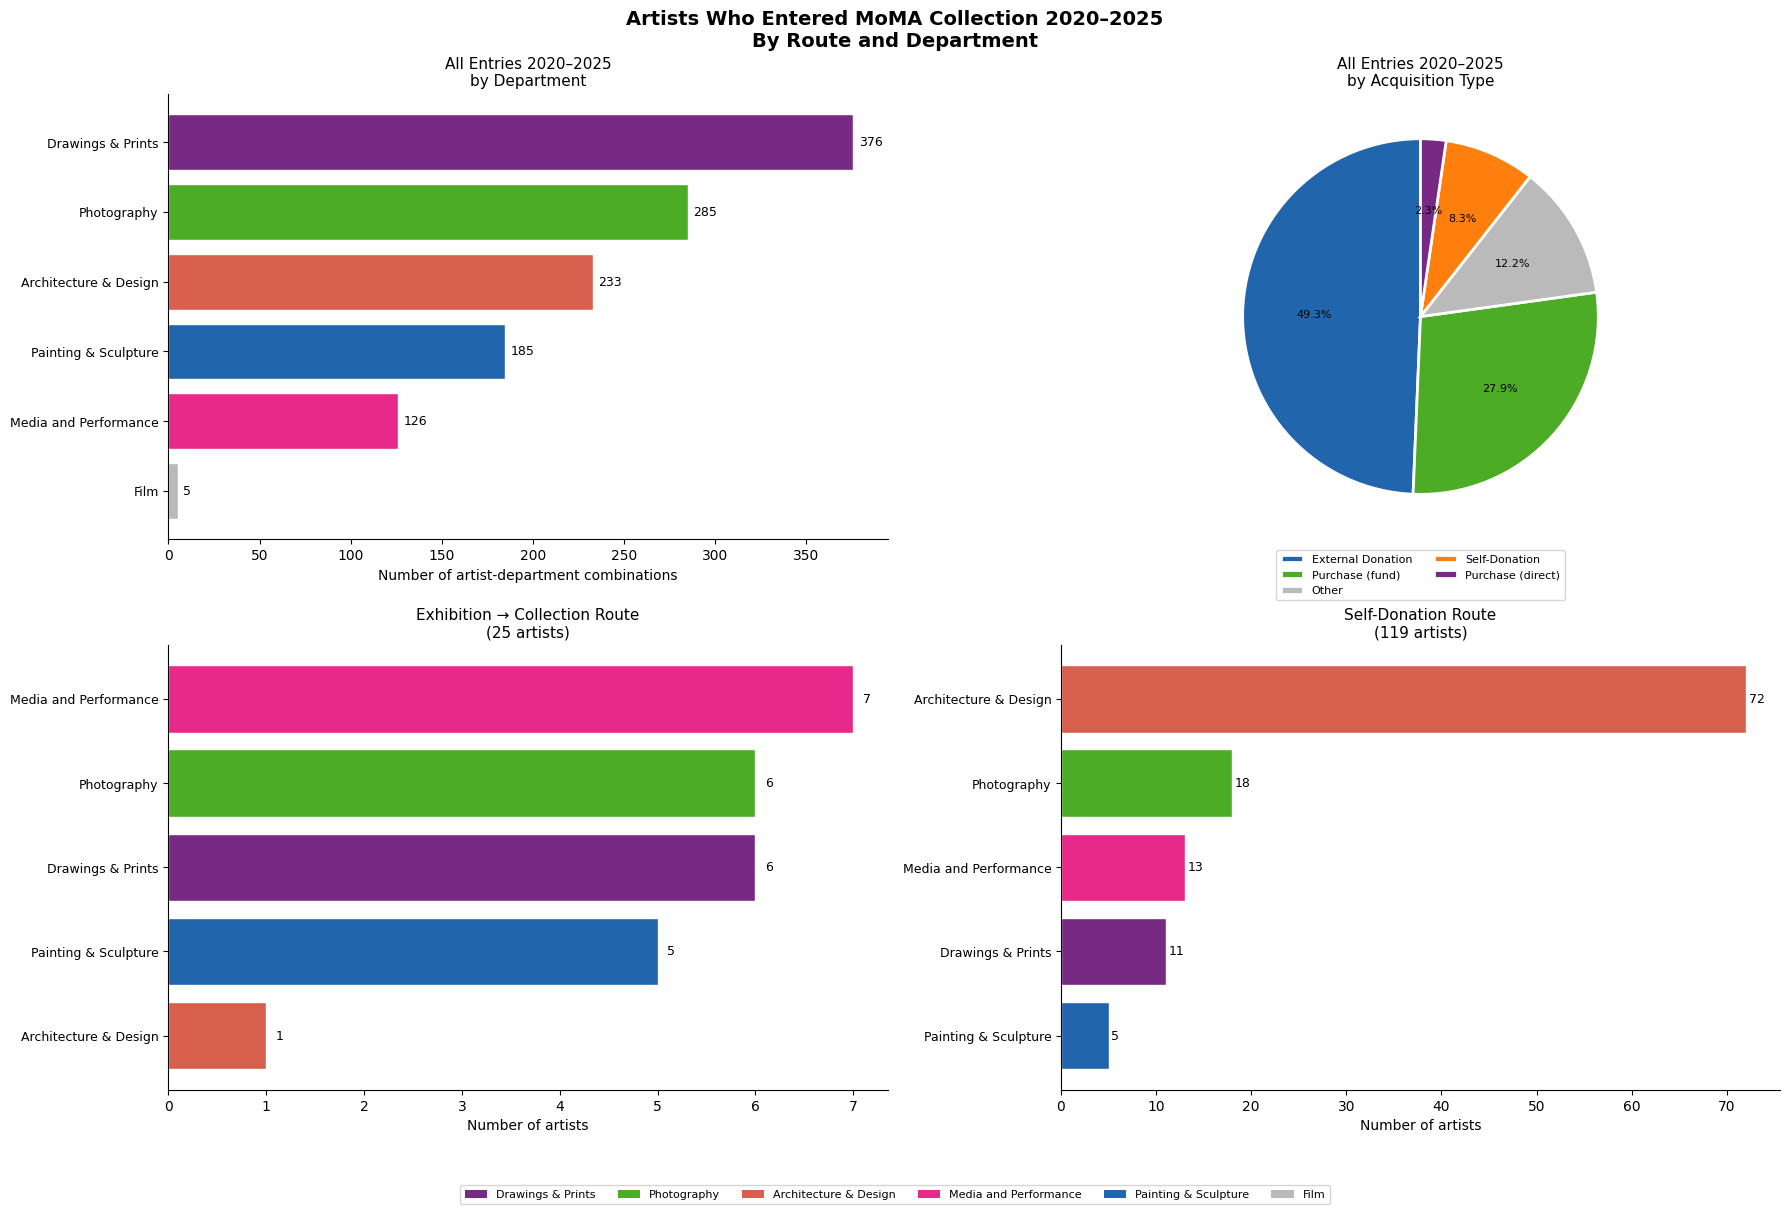

Saved.


In [62]:
# Save the key artists lists
print("=== SAVING KEY ARTIST LISTS ===\n")

# List 1: Exhibition → Collection 2020s (25 artists)
group1_names = results_df[['artist','department','acquisition_type',
                            'exhibition_year','acquired_year','gap',
                            'credit_line','exhibition']].copy()
group1_names.to_csv('data/artists_exhibition_to_collection_2020s.csv', index=False)
print(f"Saved: artists_exhibition_to_collection_2020s.csv ({len(group1_names)} artists)")

# List 2: Self-donation 2020-2025
self_2020_save = self_2020.groupby('Artist').agg(
    nationality=('Nationality','first'),
    department=('Department','first'),
    works=('Title','count'),
    year_acquired=('YearAcquired','min'),
    credit=('CreditLine','first')
).reset_index()
self_2020_save.to_csv('data/artists_self_donation_2020s.csv', index=False)
print(f"Saved: artists_self_donation_2020s.csv ({len(self_2020_save)} artists)")

# List 3: Overlap
print(f"\nOverlap (exhibited AND self-donated 2020s): {len(overlap)} artists")
for name in sorted(overlap):
    print(f"  {name}")

# Now generate the chart
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Artists Who Entered MoMA Collection 2020–2025\nBy Route and Department',
             fontsize=14, fontweight='bold')

dept_colors = {
    'Drawings & Prints':    '#762a83',
    'Photography':          '#4dac26',
    'Architecture & Design':'#d6604d',
    'Media and Performance':'#e7298a',
    'Painting & Sculpture': '#2166ac',
    'Film':                 '#bababa',
}

acq_colors = {
    'External Donation': '#2166ac',
    'Purchase (fund)':   '#4dac26',
    'Self-Donation':     '#ff7f0e',
    'Purchase (direct)': '#762a83',
    'Other':             '#bababa',
}

# ── Chart 1: All entries 2020-2025 by department ──
ax1 = axes[0, 0]
dept_counts = all_entered['Department'].value_counts()
colors1 = [dept_colors.get(d, '#d9d9d9') for d in dept_counts.index]
bars1 = ax1.barh(range(len(dept_counts)), dept_counts.values,
                 color=colors1, edgecolor='white')
ax1.set_yticks(range(len(dept_counts)))
ax1.set_yticklabels(dept_counts.index, fontsize=9)
ax1.invert_yaxis()
ax1.set_title('All Entries 2020–2025\nby Department', fontsize=11)
ax1.set_xlabel('Number of artist-department combinations')
for bar, val in zip(bars1, dept_counts.values):
    ax1.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: All entries by acquisition type ──
ax2 = axes[0, 1]
acq_counts = all_entered['acq_type'].value_counts()
colors2 = [acq_colors.get(a, '#d9d9d9') for a in acq_counts.index]
wedges, texts, autotexts = ax2.pie(
    acq_counts.values, colors=colors2,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(8)
ax2.legend(wedges, acq_counts.index, fontsize=8,
           loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
ax2.set_title('All Entries 2020–2025\nby Acquisition Type', fontsize=11)

# ── Chart 3: Exhibition → Collection group by dept ──
ax3 = axes[1, 0]
g1_dept = results_df['department'].value_counts()
colors3 = [dept_colors.get(d, '#d9d9d9') for d in g1_dept.index]
bars3 = ax3.barh(range(len(g1_dept)), g1_dept.values,
                 color=colors3, edgecolor='white')
ax3.set_yticks(range(len(g1_dept)))
ax3.set_yticklabels(g1_dept.index, fontsize=9)
ax3.invert_yaxis()
ax3.set_title('Exhibition → Collection Route\n(25 artists)', fontsize=11)
ax3.set_xlabel('Number of artists')
for bar, val in zip(bars3, g1_dept.values):
    ax3.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── Chart 4: Self-donation group by dept ──
ax4 = axes[1, 1]
g2_dept = self_2020_artists['department'].value_counts()
colors4 = [dept_colors.get(d, '#d9d9d9') for d in g2_dept.index]
bars4 = ax4.barh(range(len(g2_dept)), g2_dept.values,
                 color=colors4, edgecolor='white')
ax4.set_yticks(range(len(g2_dept)))
ax4.set_yticklabels(g2_dept.index, fontsize=9)
ax4.invert_yaxis()
ax4.set_title('Self-Donation Route\n(119 artists)', fontsize=11)
ax4.set_xlabel('Number of artists')
for bar, val in zip(bars4, g2_dept.values):
    ax4.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# Shared legend
legend_elements = [mpatches.Patch(facecolor=v, label=k) 
                   for k, v in dept_colors.items()]
fig.legend(handles=legend_elements, fontsize=8,
           loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('data/artists_entered_2020s.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [65]:
print("=== MATCHING BY CONSTITUENTID ===\n")

# Get ConstituentIDs from Artworks.csv for our target artists
all_recent_ids = []

for artist in all_recent:
    first_word = artist.split()[0]
    matches = df_art[
        df_art['Artist'].str.contains(first_word, na=False, case=False) &
        df_art['Artist'].str.contains(
            artist.split()[-1] if len(artist.split()) > 1 else first_word,
            na=False, case=False)
    ][['Artist', 'ConstituentID']].drop_duplicates()
    
    if len(matches) > 0:
        cid = matches.iloc[0]['ConstituentID']
        # Handle multiple IDs
        cid_clean = str(cid).split(',')[0].strip()
        all_recent_ids.append({
            'artist_name': artist,
            'constituentID': cid_clean,
            'matched_name': matches.iloc[0]['Artist']
        })

ids_df = pd.DataFrame(all_recent_ids)
print(f"Artists matched with ConstituentID: {len(ids_df)} of {len(all_recent)}")

# Now get WikidataID via ConstituentID
artists_csv['ConstituentID'] = artists_csv['ConstituentID'].astype(str)
ids_df['constituentID'] = ids_df['constituentID'].astype(str)

merged = ids_df.merge(
    artists_csv[['ConstituentID','DisplayName','Wiki QID','ULAN','Nationality','BeginDate']],
    left_on='constituentID', right_on='ConstituentID', how='left'
)

has_wiki = merged[merged['Wiki QID'].notna()]
no_wiki = merged[merged['Wiki QID'].isna()]

print(f"With WikidataID: {len(has_wiki)}")
print(f"Without WikidataID: {len(no_wiki)}")

print(f"\n=== ARTISTS WITH WIKIDATA ID ===")
for _, row in has_wiki.iterrows():
    print(f"  {row['artist_name'][:40]} | {row['Wiki QID']} | {row['Nationality']}")

print(f"\n=== ARTISTS WITHOUT WIKIDATA ID ===")
for _, row in no_wiki.iterrows():
    print(f"  {row['artist_name'][:40]} | ConstituentID: {row['constituentID']}")

# Save corrected list
with open('data/artists_for_wikidata.json', 'w') as f:
    json.dump({
        'total': len(all_recent),
        'with_wikidata': has_wiki[['artist_name','Wiki QID','Nationality','BeginDate']].to_dict('records'),
        'without_wikidata': no_wiki['artist_name'].tolist()
    }, f, indent=2)

print(f"\nSaved: data/artists_for_wikidata.json")

=== MATCHING BY CONSTITUENTID ===

Artists matched with ConstituentID: 144 of 144
With WikidataID: 23
Without WikidataID: 121

=== ARTISTS WITH WIKIDATA ID ===
  Andrés Jaque, Office for Political Innov | Q1096098 | Spanish
  Alex Katz | Q919265 | American
  Isaac Julien | Q328137 | British
  Mark Manders | Q826213 | Dutch
  Sheila Hicks | Q3481752 | American
  Julian Schnabel | Q345379 | American
  Arturo Herrera | Q4532609 | Venezuelan
  Andrés Jaque | Q1096098 | Spanish
  Mako Idemitsu | Q18619304 | Japanese
  Paulina Olowska | Q4275768 | British
  Liliana Porter | Q528501 | American
  Josef Koudelka | Q918352 | Czech
  James Welling | Q6145303 | American
  Emilio Ambasz | Q655905 | Argentine
  Bridget Riley | Q234449 | British
  April Greiman | Q4782033 | American
  Elizabeth Diller, Ricardo Scofidio, Dill | Q1225543 | American
  Amy Sillman | Q365691 | Icelandic
  Joan Jonas | Q453808 | American
  Christopher Wool | Q1087064 | American
  Michael Craig-Martin | Q24503 | British
  C

In [63]:
print("=== EXHIBITIONS GENERATED BY DONATIONS ===\n")
print("Looking for donor names in exhibition titles and descriptions\n")

# Top donors from P&S debuts
key_donors = [
    'Joyner', 'Giuffrida', 'Brown', 'Diefenbach', 'Pigozzi',
    'Tisch', 'Tamer', 'Cohen', 'Hess', 'Zirin', 'Ebers',
    'Heyman', 'Kravis', 'Gund', 'Ehrenkranz', 'Rockefeller',
    'Paley', 'Haupt', 'Berman', 'Pulitzer'
]

# Search in exhibition titles and descriptions
with open('data/scraped/exhibitions_raw.json') as f:
    exhibitions = json.load(f)

matches = []
for ex in exhibitions:
    title = ex.get('title', '').replace('\n', ' ')
    desc = ex.get('description', '') or ''
    year = extract_year(ex.get('date', ''))
    combined = (title + ' ' + desc).lower()
    
    for donor in key_donors:
        if donor.lower() in combined:
            matches.append({
                'exhibition_id': ex['id'],
                'title': title[:60],
                'year': year,
                'donor_match': donor,
                'description': desc[:150]
            })
            break

matches_df = pd.DataFrame(matches)
print(f"Exhibitions mentioning key donors: {len(matches_df)}")
print(f"\nBy donor:")
print(matches_df['donor_match'].value_counts())
print(f"\nFull list:")
for _, row in matches_df.sort_values('year').iterrows():
    print(f"\n  {row['year']} — {row['title']}")
    print(f"  Donor: {row['donor_match']}")
    if row['description']:
        print(f"  Desc: {row['description'][:100]}")

=== EXHIBITIONS GENERATED BY DONATIONS ===

Looking for donor names in exhibition titles and descriptions

Exhibitions mentioning key donors: 24

By donor:
donor_match
Rockefeller    8
Kravis         5
Berman         3
Cohen          3
Gund           2
Brown          2
Heyman         1
Name: count, dtype: int64

Full list:

  1936.0 — New Acquisitions: The Collection of Mrs. John D. Rockefeller
  Donor: Rockefeller
  Desc: If you would like to reproduce an image of a work of art in MoMA’s collection, or an image of a MoMA

  1946.0 — Ballet Drawings by Franklin C. Watkins for "Transcendence"; 
  Donor: Berman
  Desc: Ballet Drawings by Franklin
C. Watkins for
"Transcendence"; Model by
Eugene Berman for "The Island G

  1947.0 — The Theatre of Eugene Berman
  Donor: Berman
  Desc: In 2018–19, MoMA collaborated with Google Arts & Culture Lab on a project using machine learning to 

  1948.0 — Recent Acquisitions: Bequest of Mrs. John D. Rockefeller, Jr
  Donor: Rockefeller
  Desc: In 201

In [27]:
import json
import re
from collections import Counter

with open('data/scraped/exhibitions_raw.json') as f:
    exhibitions = json.load(f)

def extract_year(date_str):
    if not date_str:
        return None
    years = re.findall(r'\b(19\d{2}|20\d{2})\b', date_str)
    return int(years[0]) if years else None

print("=== WHAT WE HAVE IN THE SCRAPE ===\n")
print(f"Total exhibitions scraped: {len(exhibitions):,}")

# Clean vs dirty
dirty = [ex for ex in exhibitions 
         if any('\n' in a.get('name','') or '\xa0' in a.get('name','') 
                for a in ex.get('artists',[]))]
clean = len(exhibitions) - len(dirty)
print(f"Clean (usable): {clean:,} ({clean/len(exhibitions)*100:.1f}%)")
print(f"Still dirty: {len(dirty):,} ({len(dirty)/len(exhibitions)*100:.1f}%)")

# Year coverage
years = [extract_year(ex.get('date','')) for ex in exhibitions]
years = [y for y in years if y]
year_counts = Counter(years)

print(f"\nYear range: {min(years)} to {max(years)}")
print(f"Exhibitions with date: {len(years):,} of {len(exhibitions):,}")

print(f"\nBy decade:")
decades = Counter((y//10)*10 for y in years)
for decade in sorted(decades):
    print(f"  {decade}s: {decades[decade]}")

# Artist coverage
total_artists = sum(len(ex.get('artists',[])) for ex in exhibitions)
exhs_with_artists = sum(1 for ex in exhibitions if len(ex.get('artists',[])) > 0)
exhs_no_artists = sum(1 for ex in exhibitions if len(ex.get('artists',[]))==0)

print(f"\nExhibitions with at least 1 artist: {exhs_with_artists:,}")
print(f"Exhibitions with NO artists: {exhs_no_artists:,}")
print(f"Total artist-exhibition pairs: {total_artists:,}")

# ID range
ids = [ex['id'] for ex in exhibitions]
print(f"\nID range scraped: {min(ids)} to {max(ids)}")
print(f"Total IDs attempted: {max(ids) - min(ids) + 1:,}")
print(f"Hit rate: {len(exhibitions)/(max(ids)-min(ids)+1)*100:.1f}%")

=== WHAT WE HAVE IN THE SCRAPE ===

Total exhibitions scraped: 2,993
Clean (usable): 2,664 (89.0%)
Still dirty: 329 (11.0%)

Year range: 1929 to 2022
Exhibitions with date: 2,985 of 2,993

By decade:
  1920s: 2
  1930s: 132
  1940s: 253
  1950s: 225
  1960s: 286
  1970s: 630
  1980s: 664
  1990s: 222
  2000s: 284
  2010s: 278
  2020s: 9

Exhibitions with at least 1 artist: 2,596
Exhibitions with NO artists: 397
Total artist-exhibition pairs: 7,776

ID range scraped: 1700 to 5144
Total IDs attempted: 3,445
Hit rate: 86.9%
